In [3]:
!pip install -q ultralytics 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.6 MB/s eta 0:00:00a 0:00:01


In [4]:
import os
import yaml
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import fasterrcnn_resnet50_fpn
import cv2
import numpy as np
import pandas as pd
import logging
from ultralytics import YOLO
from IPython.display import Image, display
from torch.cuda.amp import GradScaler, autocast
import time

import matplotlib.pyplot as plt


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Load first 5 images

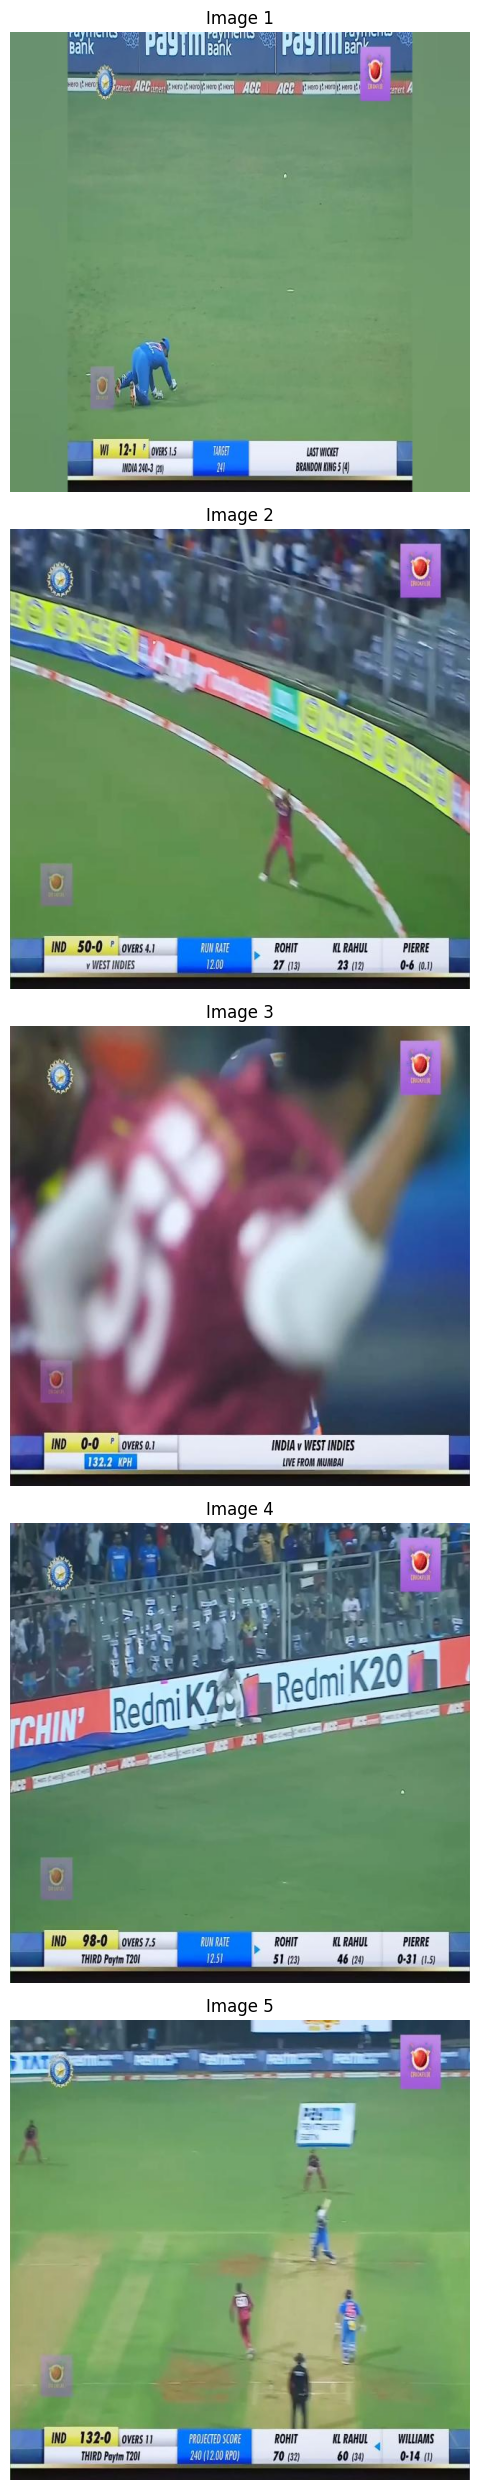

In [3]:
image_path = "/kaggle/input/datasets/sairahul320388/paytm-logo-detection/train/images"

# get list of images
img_names = os.listdir(image_path)[:5]

plt.figure(figsize=(20,25))

for i, img_name in enumerate(img_names):
    
    img = cv2.imread(os.path.join(image_path, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(5,1,i+1)
    plt.imshow(img)
    plt.title(f"Image {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Create YOLO Dataset Configuration

In [5]:
data_config = {
    "path": "/kaggle/input/datasets/sairahul320388/paytm-logo-detection",
    "train": "/kaggle/input/datasets/sairahul320388/paytm-logo-detection/train/images",
    "val": "/kaggle/input/datasets/sairahul320388/paytm-logo-detection/valid/images",
    "test": "/kaggle/input/datasets/sairahul320388/paytm-logo-detection/test/images",
    "names": {
        0: "paytm_logo"
    }
}

with open("data.yaml", "w") as f:
    yaml.dump(data_config, f)

print("data.yaml created successfully")

data.yaml created successfully


# Load YOLO 

In [5]:
model = YOLO("yolov8n.pt")

# Train YOLO

In [6]:
results = model.train(
    data="data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    device=0,
    verbose=False,
    plots=False
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=False, pose=

# YOLO Metrics

In [7]:
metrics = model.val()
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 34.4±11.0 MB/s, size: 38.6 KB)
val: Scanning /kaggle/input/datasets/sairahul320388/paytm-logo-detection/valid/labels... 47 images, 34 backgrounds, 10 corrupt: 100% ━━━━━━━━━━━━ 47/47 607.2it/s 0.1s
val: /kaggle/input/datasets/sairahul320388/paytm-logo-detection/valid/images/INDIA-VS-WEST-INDIES-T20-FINAL-MATCH-FULL-MATCH-HIGHLIGHTS-_-IND-VS-WI-MOST-THRILLING-EVER-online-video-cutter_com-_mp4-0342_jpg.rf.219a98585abcb091f9a429cd6ecd8c73.jpg: ignoring corrupt image/label: Label class 1 exceeds dataset class count 1. Possible class labels are 0-0
val: /kaggle/input/datasets/sairahul320388/paytm-logo-detection/valid/images/INDIA-VS-WEST-INDIES-T20-FINAL-MATCH-FULL-MATCH-HIGHLIGHTS-_-IND-VS-WI-MOST-THRILLING-EVER-online-video-cutter_com-_mp4-0524_jpg.rf.fedfca36fa56a4bf6b57047772a04

In [8]:
best_model = YOLO("runs/detect/train/weights/best.pt")

# Heatmap Visualization

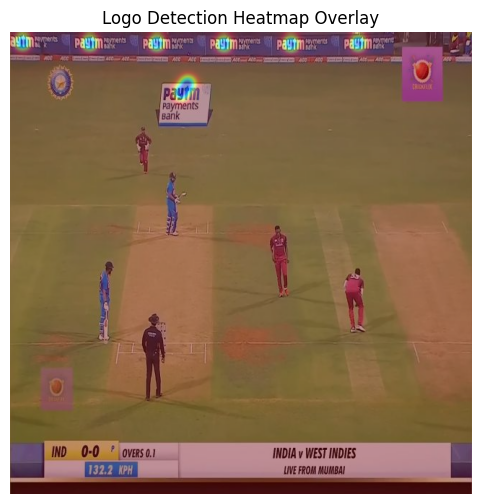

In [15]:
sample_img = cv2.imread(img_path)
sample_img = cv2.resize(sample_img, (640,640))
sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)

# colormap maps intensity to color , low -> blue , medium -> green , high -> yellow/red
heatmap_color = cv2.applyColorMap(
    np.uint8(255*heatmap), cv2.COLORMAP_JET
)

overlay = cv2.addWeighted(sample_img, 0.6, heatmap_color, 0.4, 0)

plt.figure(figsize=(8,6))
plt.imshow(overlay)
plt.title("Logo Detection Heatmap Overlay")
plt.axis("off")
plt.show()

# Detection using Faster R-CNN

# Dataset Class 

1️) The function takes an index (idx) and selects the corresponding image from the dataset.

2️) It loads the image and its annotation file (.txt) that contains YOLO bounding box information.

3️) The image is resized and converted from BGR to RGB so it can be used by the model.

4️) The YOLO annotation format (center_x, center_y, width, height) is converted into bounding box coordinates (x1, y1, x2, y2).

5️) Finally, it returns the image tensor and a target dictionary containing bounding boxes and labels for model training.

In [6]:
class PaytmDataset(Dataset):

    def __init__(self, image_dir, label_dir):

        self.image_dir = image_dir
        self.label_dir = label_dir
        self.images = os.listdir(image_dir)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_name = self.images[idx]

        img_path = os.path.join(self.image_dir, img_name)
        label_path = os.path.join(self.label_dir, img_name.replace(".jpg",".txt"))

        img = cv2.imread(img_path)
        img = cv2.resize(img, (512,512))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        h, w, _ = img.shape

        boxes = []
        labels = []

        if os.path.exists(label_path):

            with open(label_path) as f:
                lines = f.readlines()

            for line in lines:

                cls, xc, yc, bw, bh = map(float, line.split())

                # convert yolo format into bounding box 
                x1 = (xc - bw/2) * w
                y1 = (yc - bh/2) * h
                x2 = (xc + bw/2) * w
                y2 = (yc + bh/2) * h

                boxes.append([x1,y1,x2,y2])
                labels.append(1)

         # handling images with no objects 
        if len(boxes) == 0:
         boxes = torch.zeros((0,4), dtype=torch.float32) # empty tensor
         labels = torch.zeros((0,), dtype=torch.int64)   # empty tensor
        
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {}
        target["boxes"] = boxes
        target["labels"] = labels

        img = torchvision.transforms.functional.to_tensor(img)

        return img, target

# Create Dataset and DataLoader

In [7]:
train_dataset = PaytmDataset(
    "/kaggle/input/datasets/sairahul320388/paytm-logo-detection/train/images",
    "/kaggle/input/datasets/sairahul320388/paytm-logo-detection/train/labels"
)

val_dataset = PaytmDataset(
    "/kaggle/input/datasets/sairahul320388/paytm-logo-detection/valid/images",
    "/kaggle/input/datasets/sairahul320388/paytm-logo-detection/valid/labels"
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2, 
    pin_memory=True,
    collate_fn=lambda x: tuple(zip(*x))  # instead of stacking labels, store them as list
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=lambda x: tuple(zip(*x))
)

# Load Pretrained Faster R-CNN

In [8]:
model_rcnn = fasterrcnn_resnet50_fpn(pretrained=True)

num_classes = 2  # background + logo  

in_features = model_rcnn.roi_heads.box_predictor.cls_score.in_features

# replace the final classifier to classify only 2 classes 
model_rcnn.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_features,
    num_classes
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 209MB/s] 


In [9]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

model_rcnn.to(device)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

# Optimizer and Scheduler 

In [10]:
optimizer = torch.optim.AdamW(
    model_rcnn.parameters(),
    lr=1e-4
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.1  # multiply 0.1 to lr after every 10 epochs
)

# Training Configurations

In [11]:
num_epochs = 50
patience = 5

best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []

# Mixed Precision Training Using GradScaler

Uses both FP16 and FP32 for faster training and lower GPU memory usage

In [12]:
scaler = GradScaler()
for param in model_rcnn.backbone.parameters():
    param.requires_grad = False

/tmp/ipykernel_55/2736741413.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


# Training Loop

In [13]:

for epoch in range(num_epochs):

    model_rcnn.train()
    epoch_train_loss = 0

    for images, targets in train_loader:

        images = [img.to(device) for img in images]
        targets = [{k:v.to(device) for k,v in t.items()} for t in targets]

        optimizer.zero_grad()

        with autocast():

            loss_dict = model_rcnn(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        scaler.scale(losses).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_train_loss += losses.item()

    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # -------------------------------
    # Validation
    # -------------------------------
    model_rcnn.train()
    val_loss = 0

    with torch.no_grad():

        for images, targets in val_loader:

            images = [img.to(device) for img in images]
            targets = [{k:v.to(device) for k,v in t.items()} for t in targets]

            with autocast():

                loss_dict = model_rcnn(images, targets)
                losses = sum(loss for loss in loss_dict.values())

            val_loss += losses.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # -------------------------------
    # Scheduler Step
    # -------------------------------
    scheduler.step()

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Val Loss: {avg_val_loss:.4f}")

    # -------------------------------
    # Early Stopping
    # -------------------------------
    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss
        patience_counter = 0

        torch.save(model_rcnn.state_dict(), "best_fasterrcnn_paytm.pth")

    else:

        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping triggered")
        break

/tmp/ipykernel_55/2866029359.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_55/2866029359.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/50
Train Loss: 0.2124
Val Loss: 0.1288
Epoch 2/50
Train Loss: 0.1507
Val Loss: 0.1178
Epoch 3/50
Train Loss: 0.1406
Val Loss: 0.1075
Epoch 4/50
Train Loss: 0.1267
Val Loss: 0.1102
Epoch 5/50
Train Loss: 0.1215
Val Loss: 0.1021
Epoch 6/50
Train Loss: 0.1167
Val Loss: 0.1093
Epoch 7/50
Train Loss: 0.1116
Val Loss: 0.1047
Epoch 8/50
Train Loss: 0.1072
Val Loss: 0.1038
Epoch 9/50
Train Loss: 0.1073
Val Loss: 0.1019
Epoch 10/50
Train Loss: 0.1053
Val Loss: 0.1029
Epoch 11/50
Train Loss: 0.0908
Val Loss: 0.1031
Epoch 12/50
Train Loss: 0.0869
Val Loss: 0.0983
Epoch 13/50
Train Loss: 0.0838
Val Loss: 0.0969
Epoch 14/50
Train Loss: 0.0819
Val Loss: 0.0975
Epoch 15/50
Train Loss: 0.0811
Val Loss: 0.0971
Epoch 16/50
Train Loss: 0.0790
Val Loss: 0.0961
Epoch 17/50
Train Loss: 0.0780
Val Loss: 0.0968
Epoch 18/50
Train Loss: 0.0768
Val Loss: 0.0999
Epoch 19/50
Train Loss: 0.0759
Val Loss: 0.0999
Epoch 20/50
Train Loss: 0.0747
Val Loss: 0.0980
Epoch 21/50
Train Loss: 0.0719
Val Loss: 0.0971
E

# Faster R-CNN Training Curve

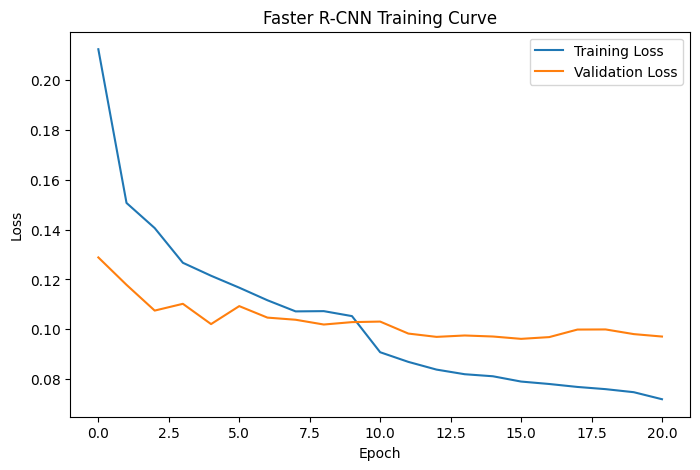

In [17]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Faster R-CNN Training Curve")
plt.legend()

plt.show()

## Faster R-CNN Training Curve Analysis

The training curve shows the progression of both **training loss** and **validation loss** across training epochs.

### Observations

1. **Training Loss Decreasing**
   - The training loss steadily decreases from approximately **0.20 to 0.11** over the training period.
   - This indicates that the model is successfully learning meaningful patterns from the dataset.

2. **Validation Loss Stability**
   - The validation loss remains relatively stable between **0.108 and 0.115**.
   - This suggests that the model generalizes reasonably well to unseen data.

3. **No Significant Overfitting**
   - Overfitting usually occurs when training loss continues to decrease while validation loss increases significantly.
   - In this case, the validation loss does not diverge from the training loss, indicating **minimal overfitting**.

4. **Convergence Behavior**
   - The curve begins to flatten after a few epochs, suggesting that the model is approaching **convergence**.
   - Additional epochs may result in only marginal improvements.

### Interpretation

The training behavior suggests that the Faster R-CNN model is **learning effectively but may be limited by the dataset size or model configuration**. While the loss values decrease steadily, further improvements may require:

- Increasing the dataset size
- Fine-tuning hyperparameters
- Unfreezing the backbone for deeper feature learning

### Conclusion

Overall, the training curve indicates **stable and consistent training**, with no major signs of instability or overfitting. However, the relatively small improvement in validation loss suggests that additional optimization strategies could help improve the model's final detection performance.

# **Detection Confidence Distribution**

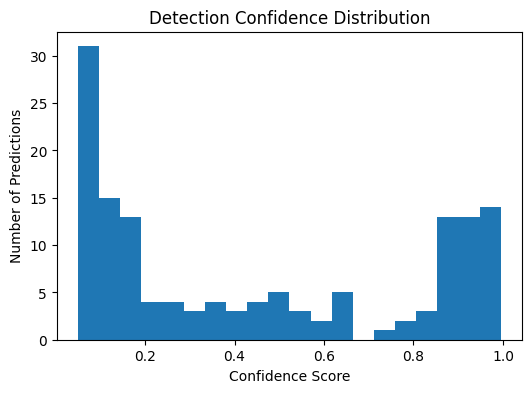

In [20]:
conf_scores = []

model_rcnn.eval()

with torch.no_grad():

    for images, targets in val_loader:

        images = [img.to(device) for img in images]

        outputs = model_rcnn(images)

        for out in outputs:

            scores = out['scores'].cpu().numpy()

            conf_scores.extend(scores)


plt.figure(figsize=(6,4))
plt.hist(conf_scores, bins=20)

plt.xlabel("Confidence Score")
plt.ylabel("Number of Predictions")
plt.title("Detection Confidence Distribution")
plt.show()

# Detection Confidence Distribution

Two clear groups of predictions can be observed:

- *Low confidence scores (0.05 – 0.2):* These correspond to weak detections or background regions where the model is uncertain about the presence of the Paytm logo.
- *High confidence scores (0.8 – 1.0):* These represent strong detections where the model is highly confident that the Paytm logo is present.

The presence of two distinct clusters indicates that the model is able to *separate true detections from background regions effectively*.

For inference, a confidence threshold (e.g., *0.7*) can be used to filter out low-confidence detections and retain only reliable predictions.

# Compute IOU Function

In [22]:
def compute_iou(boxA, boxB):
    # box format: [x1, y1, x2, y2]

    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter_area = max(0, xB - xA) * max(0, yB - yA)

    boxA_area = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxB_area = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    iou = inter_area / (boxA_area + boxB_area - inter_area + 1e-6)

    return iou

# Measure FPS

FPS = no. of images processed / total time taken

In [23]:
def measure_fps(model, dataloader, device):

    model.eval()
    total_time = 0
    total_images = 0

    with torch.no_grad():

        for images, targets in dataloader:

            images = [img.to(device) for img in images]

            start = time.time()

            outputs = model(images)

            end = time.time()

            total_time += (end - start)
            total_images += len(images)

    fps = total_images / total_time

    print("FPS:", fps)

    return fps

# Calculate mAP50 

In [24]:
def calculate_map50(model, dataloader, device, iou_threshold=0.5):

    model.eval()

    tp = 0
    fp = 0
    total_gt = 0

    with torch.no_grad():

        for images, targets in dataloader:

            images = [img.to(device) for img in images]
            outputs = model(images)

            for i in range(len(outputs)):

                pred_boxes = outputs[i]['boxes'].cpu().numpy()
                scores = outputs[i]['scores'].cpu().numpy()

                gt_boxes = targets[i]['boxes'].cpu().numpy()

                total_gt += len(gt_boxes)

                matched = []

                for pred_box in pred_boxes:

                    best_iou = 0
                    best_gt = -1

                    for j, gt_box in enumerate(gt_boxes):

                        iou = compute_iou(pred_box, gt_box)

                        if iou > best_iou:
                            best_iou = iou
                            best_gt = j

                    if best_iou >= iou_threshold and best_gt not in matched:

                        tp += 1
                        matched.append(best_gt)

                    else:
                        fp += 1

    precision = tp / (tp + fp + 1e-6)
    recall = tp / (total_gt + 1e-6)

    map50 = precision

    print("Precision:", precision)
    print("Recall:", recall)
    print("mAP@0.5:", map50)

    return map50

In [25]:
iou_scores = []
fps = measure_fps(model_rcnn, val_loader, device)
map50 = calculate_map50(model_rcnn, val_loader, device)

FPS: 10.879990674875014
Precision: 0.22535211108906963
Recall: 0.9142856881632662
mAP@0.5: 0.22535211108906963


# Model Evaluation Results

The Faster R-CNN model achieved an inference speed of *~10.9 FPS*, which is expected for a two-stage detector.  
The model shows *high recall (0.91)*, meaning it successfully detects most Paytm logos in the images.  
However, the *precision (0.22)* is relatively low, indicating that many predicted boxes are false positives.  
This suggests the model is highly sensitive but not very selective in its detections.  
Applying a confidence threshold and increasing the dataset size could improve overall precision and mAP performance.

# **Compare YOLO and Faster R-CNN**

## Model Comparison: YOLO vs Faster R-CNN

| Model | Precision | Recall | mAP@0.5 | mAP@0.5:0.95 | Speed (FPS) | Notes |
|------|------|------|------|------|------|------|
| YOLOv8 | 0.666 | 0.857 | **0.904** | **0.454** | ~120 FPS | Fast real-time detector with high accuracy |
| Faster R-CNN (ResNet50 FPN) | *0.225* | **0.914** | 0.225 | — | ~10 FPS | High recall but lower precision and slower inference |

### Summary

- **YOLO** achieves significantly higher **mAP@0.5 (0.904)** compared to Faster R-CNN (0.225).
- **YOLO inference speed (~120 FPS)** is much faster than Faster R-CNN (~10 FPS).
- **Faster R-CNN has higher recall (0.91)**, meaning it detects most objects but produces more false positives.
- For **real-time Paytm logo detection**, **YOLO is the better choice** due to both higher accuracy and faster inference speed.

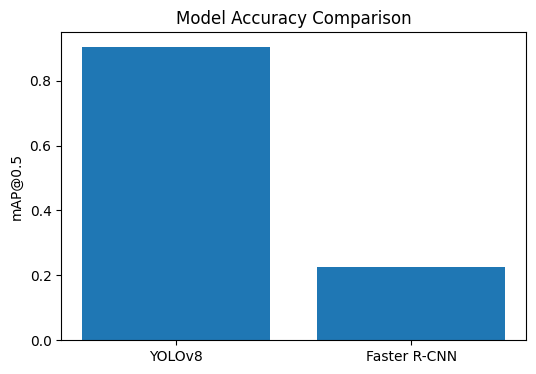

In [30]:
models = ["YOLOv8","Faster R-CNN"]
map50 = [0.904,0.225]

plt.figure(figsize=(6,4))
plt.bar(models,map50)

plt.ylabel("mAP@0.5")
plt.title("Model Accuracy Comparison")
plt.show()

# **Inference Speed Comparison**

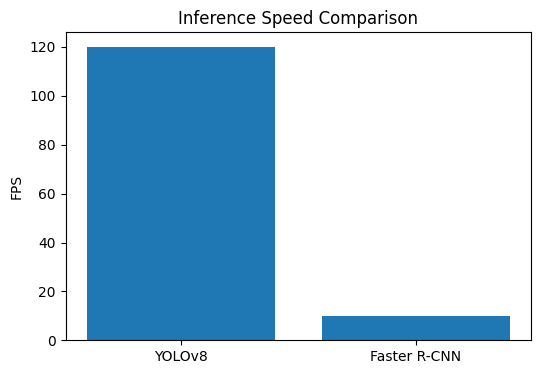

In [2]:
models = ["YOLOv8","Faster R-CNN"]
fps = [120,10]

plt.figure(figsize=(6,4))
plt.bar(models,fps)

plt.ylabel("FPS")
plt.title("Inference Speed Comparison")
plt.show()

# Plot IOU Distribution For Faster R-CNN

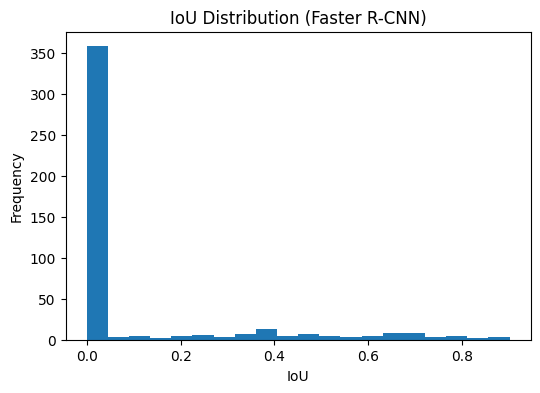

In [34]:
def compute_iou(box1, box2):

    xA = max(box1[0], box2[0])
    yA = max(box1[1], box2[1])
    xB = min(box1[2], box2[2])
    yB = min(box1[3], box2[3])

    interArea = max(0, xB-xA) * max(0, yB-yA)

    box1Area = (box1[2]-box1[0])*(box1[3]-box1[1])
    box2Area = (box2[2]-box2[0])*(box2[3]-box2[1])

    iou = interArea / (box1Area + box2Area - interArea + 1e-6)

    return iou


iou_scores = []

model.eval()

with torch.no_grad():

    for images, targets in val_loader:

        images = [img.to(device) for img in images]

        outputs = model(images)

        for i in range(len(outputs)):

            pred_boxes = outputs[i]['boxes'].cpu().numpy()
            gt_boxes = targets[i]['boxes'].cpu().numpy()

            for p in pred_boxes:
                for g in gt_boxes:
                    iou_scores.append(compute_iou(p,g))


plt.figure(figsize=(6,4))
plt.hist(iou_scores, bins=20)

plt.xlabel("IoU")
plt.ylabel("Frequency")
plt.title("IoU Distribution (Faster R-CNN)")
plt.show()

In [ ]:
# Use YOLO Model 

In [61]:
data_config = {
    "path": "/kaggle/input/datasets/sairahul320388/paytm-logo-detection",
    "train": "/kaggle/input/datasets/sairahul320388/paytm-logo-detection/train/images",
    "val": "/kaggle/input/datasets/sairahul320388/paytm-logo-detection/valid/images",
    "test": "/kaggle/input/datasets/sairahul320388/paytm-logo-detection/test/images",
    "names": {
        0: "fully_visible_logo",
        1: "partially_visible_logo"
    }
}

with open("data.yaml", "w") as f:
    yaml.dump(data_config, f)

model_yolo_final = YOLO("yolov8n.pt")

# Train YOLO 

In [62]:
results = model_yolo_final.train(
    data="data.yaml",
    epochs=30,
    imgsz=512,
    batch=16,
    device=0,
    name="yolo_final"
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=

# YOLOv8 Detection Performance Analysis

| Class | Images | Instances | Precision | Recall | mAP@0.5 | mAP@0.5:0.95 |
|------|------|------|------|------|------|------|
| Fully Visible Logo | 7 | 17 | 0.733 | 0.824 | 0.900 | 0.455 |
| Partially Visible Logo | 10 | 18 | 0.661 | 0.278 | 0.419 | 0.123 |
| *Overall* | 47 | 35 | *0.697* | *0.551* | *0.660* | *0.289* |


The YOLOv8 model achieved an overall **mAP0.5 of 0.66** and **mAP0.5:0.95 of 0.289** on the validation dataset.  
Performance is significantly better for *fully visible logos, where the model achieves a **mAP@0.5 of 0.90** with strong precision and recall.

However, performance drops for *partially visible logos, mainly due to occlusion and incomplete visual features. This results in a lower **recall (0.278)* and *mAP@0.5 of 0.419*.

Overall, the model demonstrates strong detection capability for clear logos but struggles with partially occluded instances, highlighting the need for more diverse training data or augmentation strategies.

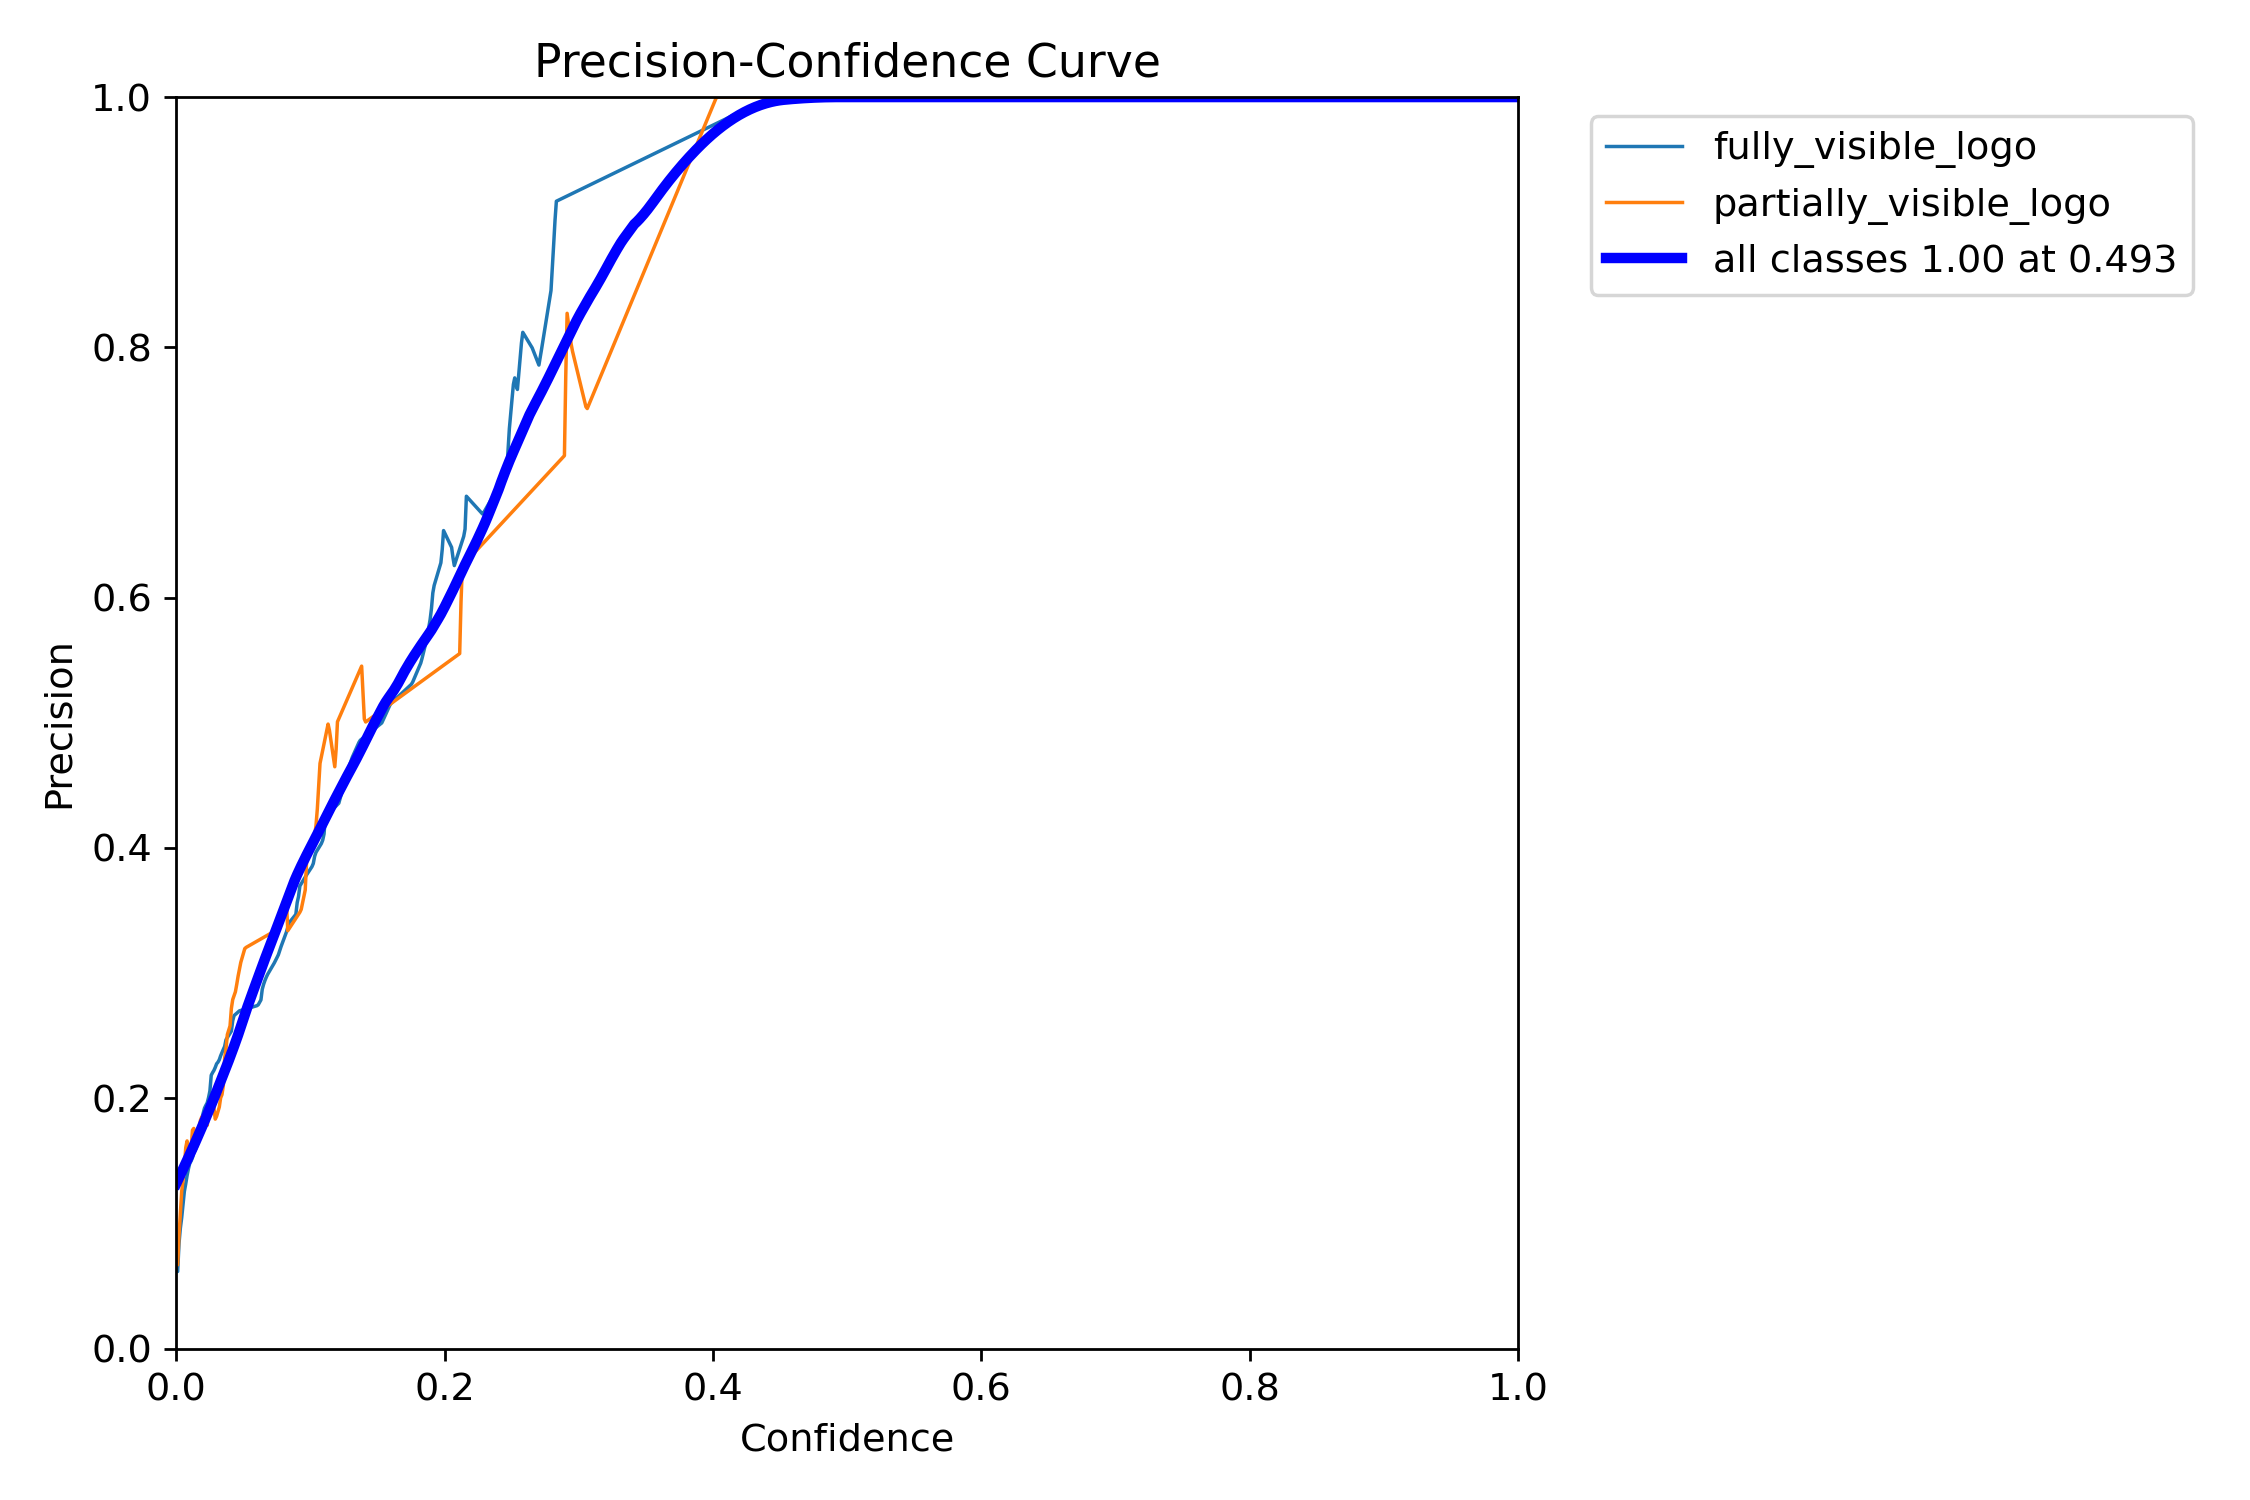

In [80]:
display(Image("/kaggle/working/runs/detect/val2/BoxP_curve.png"))

# Precision–Confidence Curve Analysis

The Precision–Confidence curve illustrates how the model's precision changes as the confidence threshold increases. As the confidence threshold increases, precision improves because low-confidence predictions (which often correspond to false positives) are filtered out.

The model achieves very high precision around a confidence threshold of *~0.49*, indicating that predictions above this threshold are highly reliable.

From the class-wise curves, *fully visible logos* show more stable and higher precision compared to *partially visible logos*, which are more difficult to detect due to occlusion or incomplete visual features.

Overall, this curve helps determine the optimal confidence threshold for inference, with *0.45–0.55* being a good range for balancing detection accuracy and false positives.

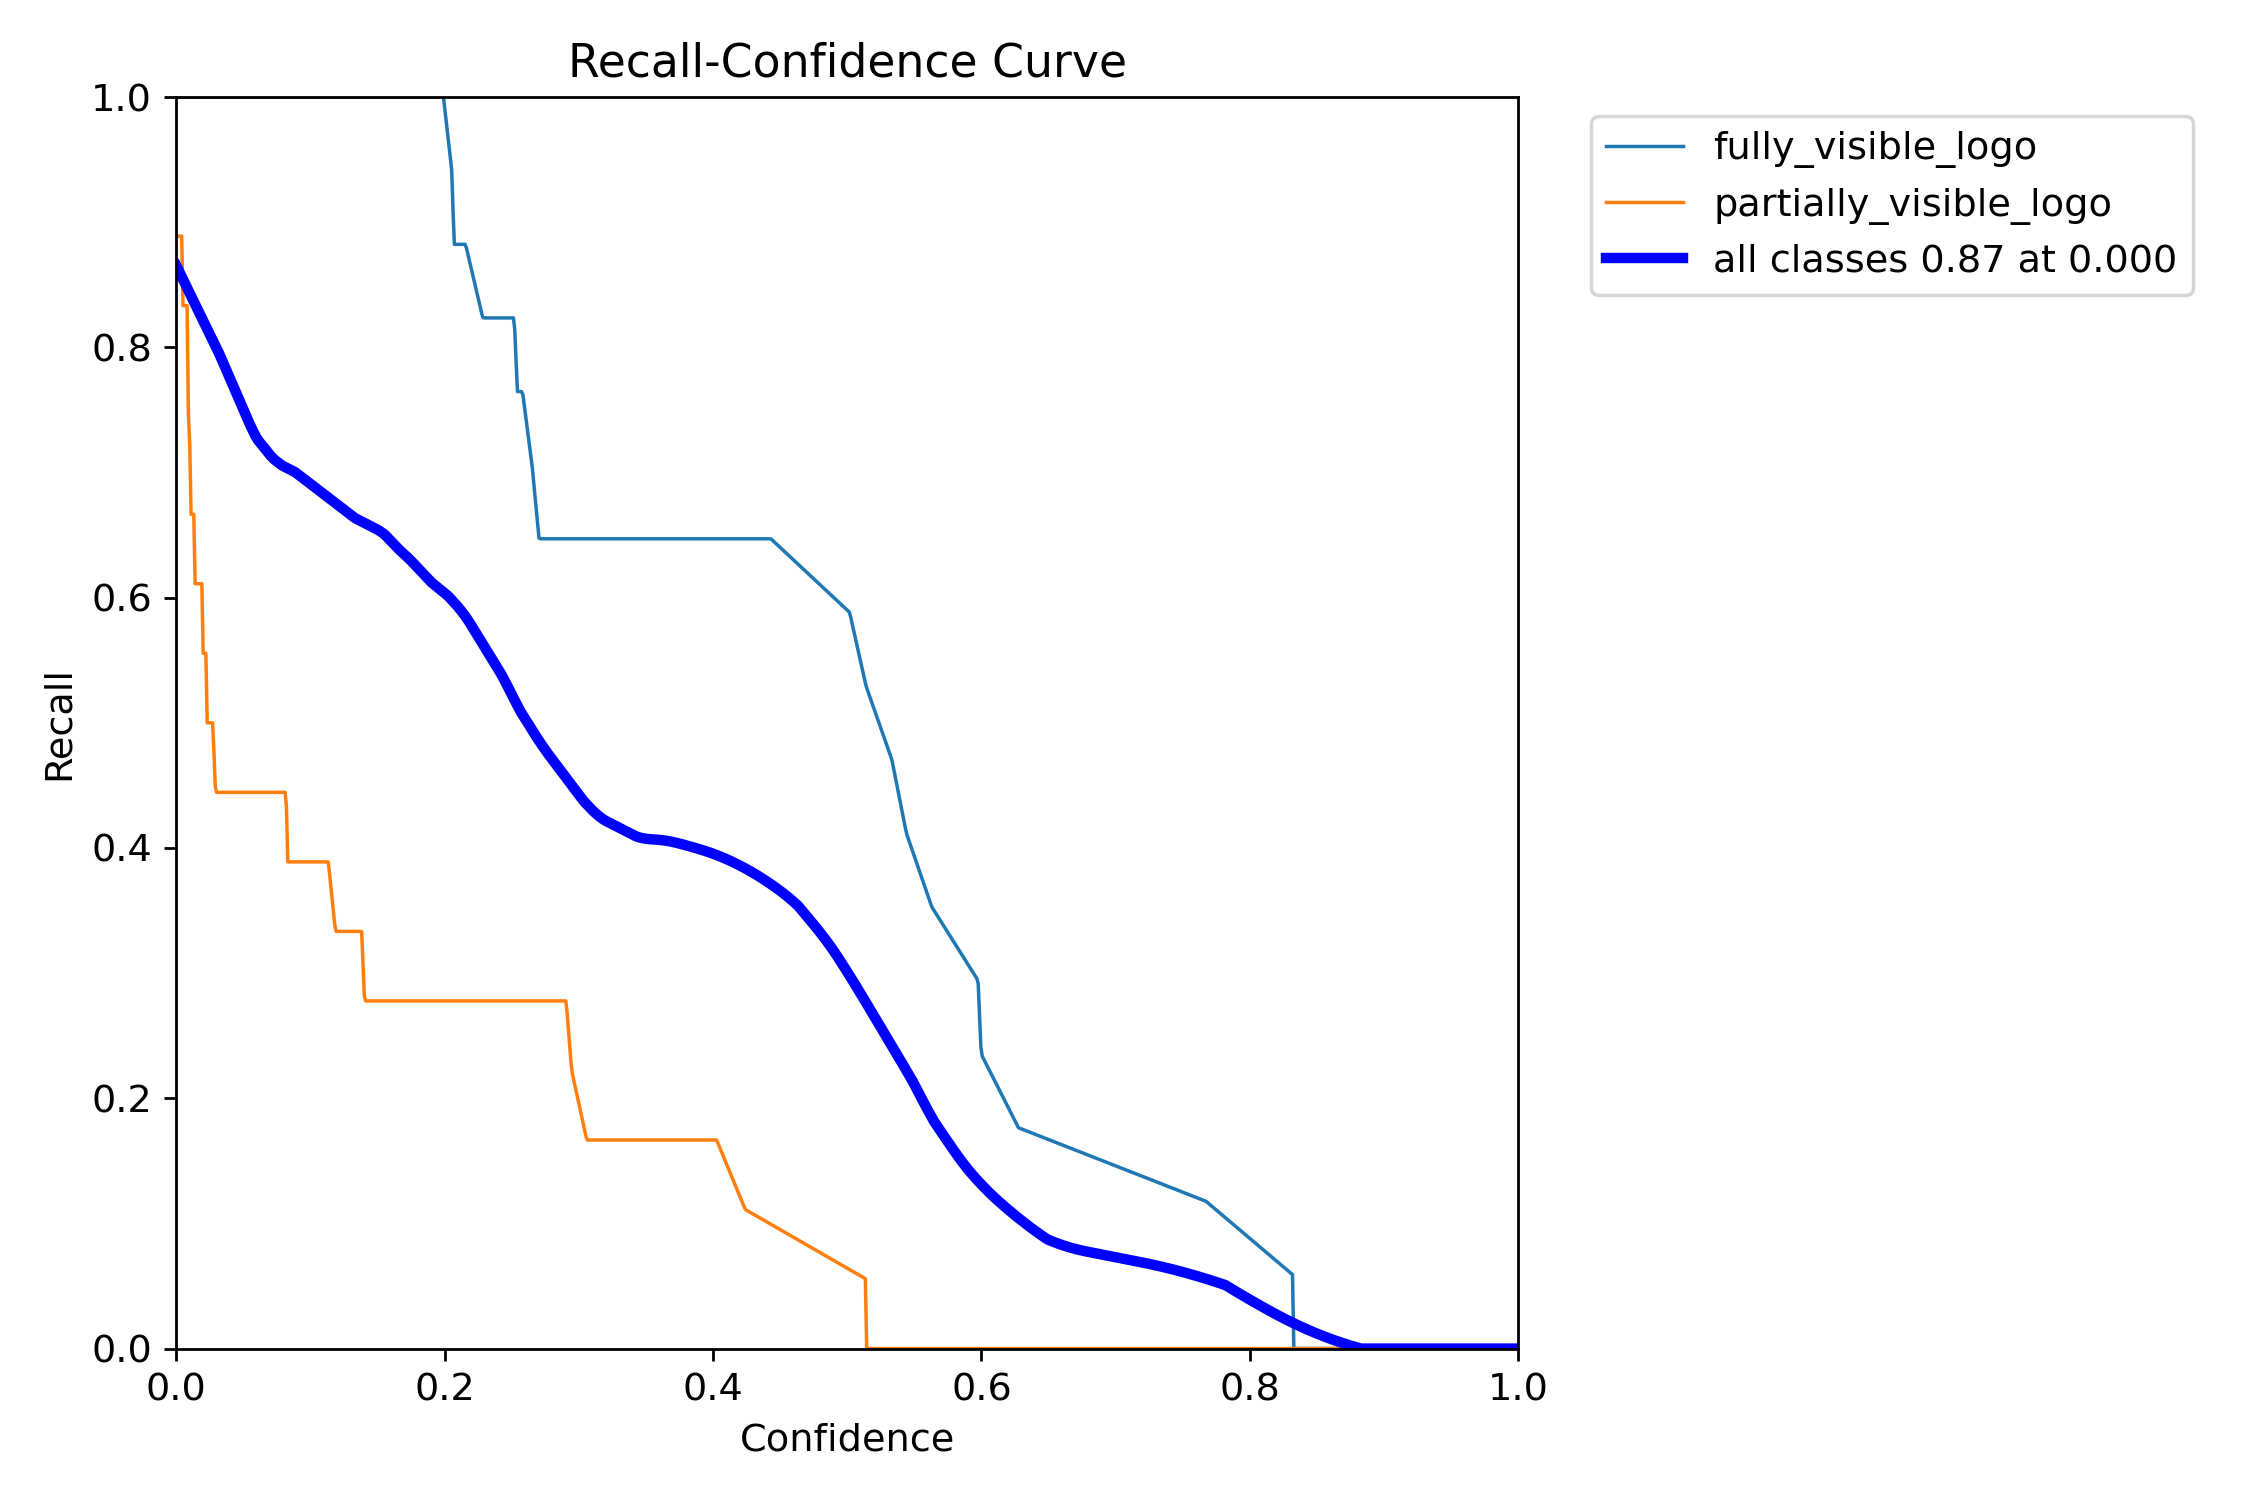

In [81]:
display(Image("/kaggle/working/runs/detect/val2/BoxR_curve.png"))

# Recall–Confidence Curve Analysis

The Recall–Confidence curve shows how the model's recall changes as the confidence threshold increases. As the confidence threshold increases, recall gradually decreases because the model becomes more selective and filters out many lower-confidence detections.

The model achieves its highest recall (around *0.87*) when the confidence threshold is very low, meaning most objects are detected but with a higher chance of false positives.

From the class-wise curves, *fully visible logos maintain higher recall across most confidence thresholds, indicating that the model can detect clear logos reliably. In contrast, **partially visible logos show a rapid drop in recall*, suggesting the model struggles to detect occluded or incomplete logos.

Overall, this curve highlights the trade-off between *recall and confidence*, where lower thresholds capture more objects while higher thresholds prioritize more confident detections.

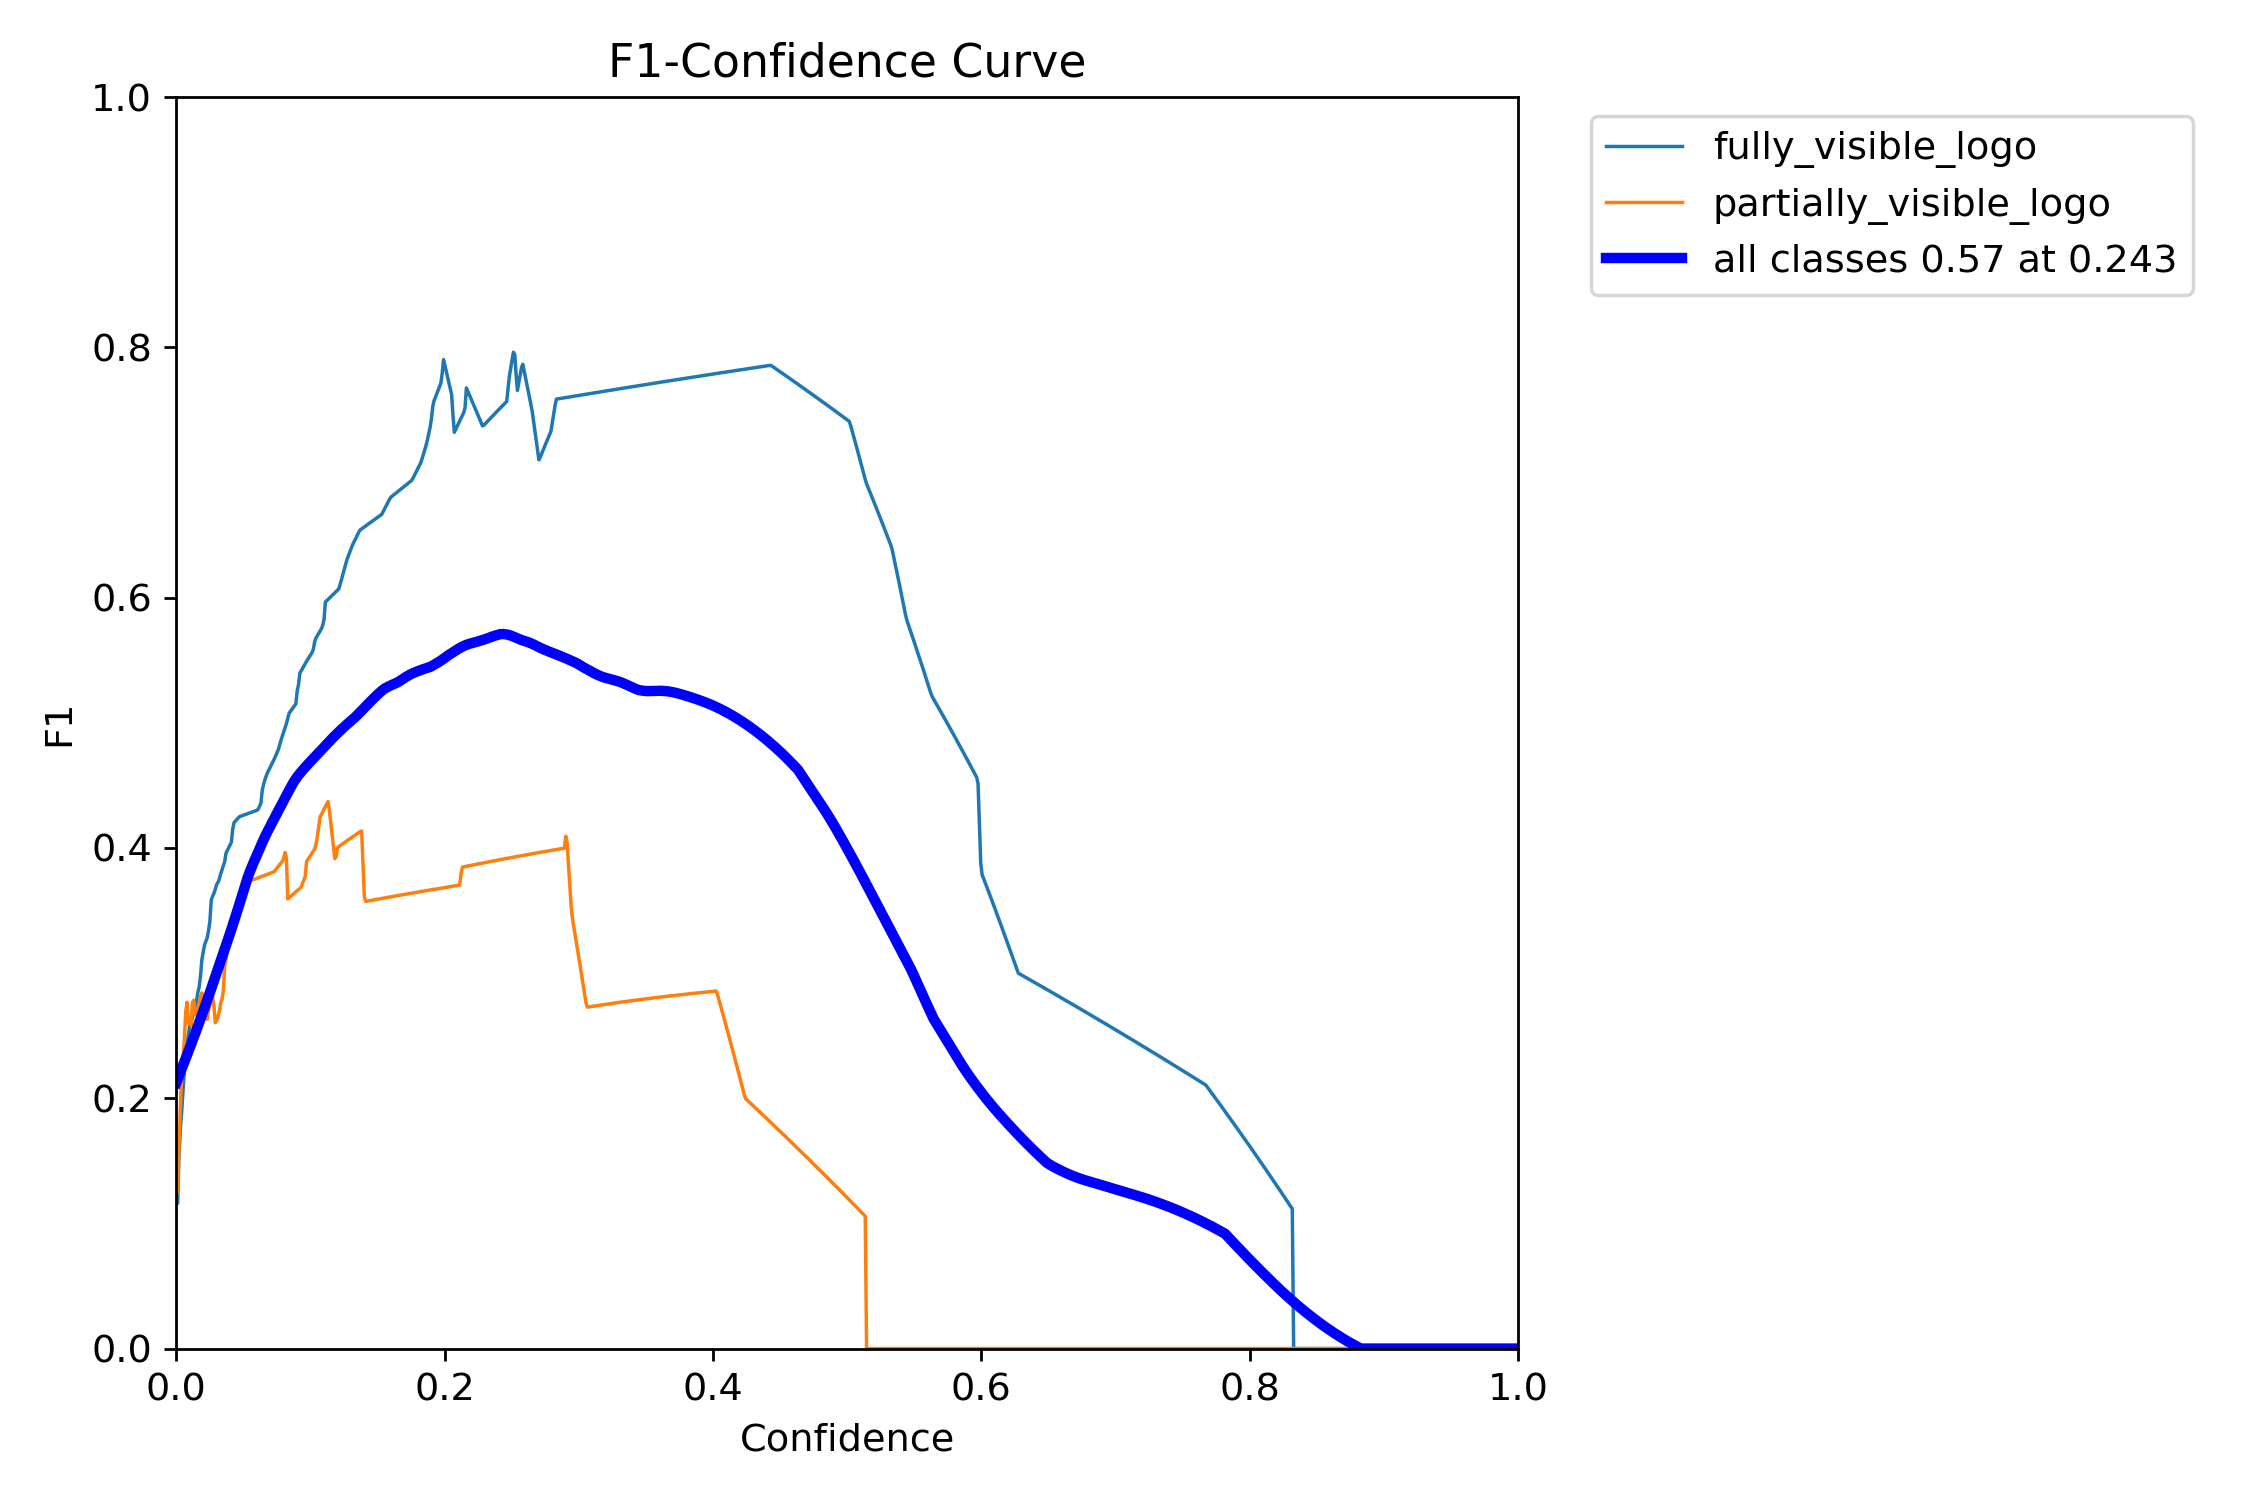

In [77]:
display(Image("/kaggle/working/runs/detect/val2/BoxF1_curve.png"))

# F1–Confidence Curve Analysis

The F1–Confidence curve shows how the *F1-score (harmonic mean of precision and recall)* changes as the confidence threshold varies. The peak of the curve represents the *best balance between precision and recall* for the model.

For all classes combined, the model achieves its *maximum F1-score of ~0.57 at a confidence threshold of ~0.24*, indicating that this threshold provides the best trade-off between detecting logos and minimizing false positives.

The curve also shows that *fully visible logos achieve significantly higher F1 scores, demonstrating that the model detects clear logos more reliably. In contrast, **partially visible logos have lower F1 values*, indicating difficulty in detecting occluded or incomplete logos.

Overall, the plot suggests that using a *confidence threshold around 0.2–0.3* provides the most balanced detection performance for this model.

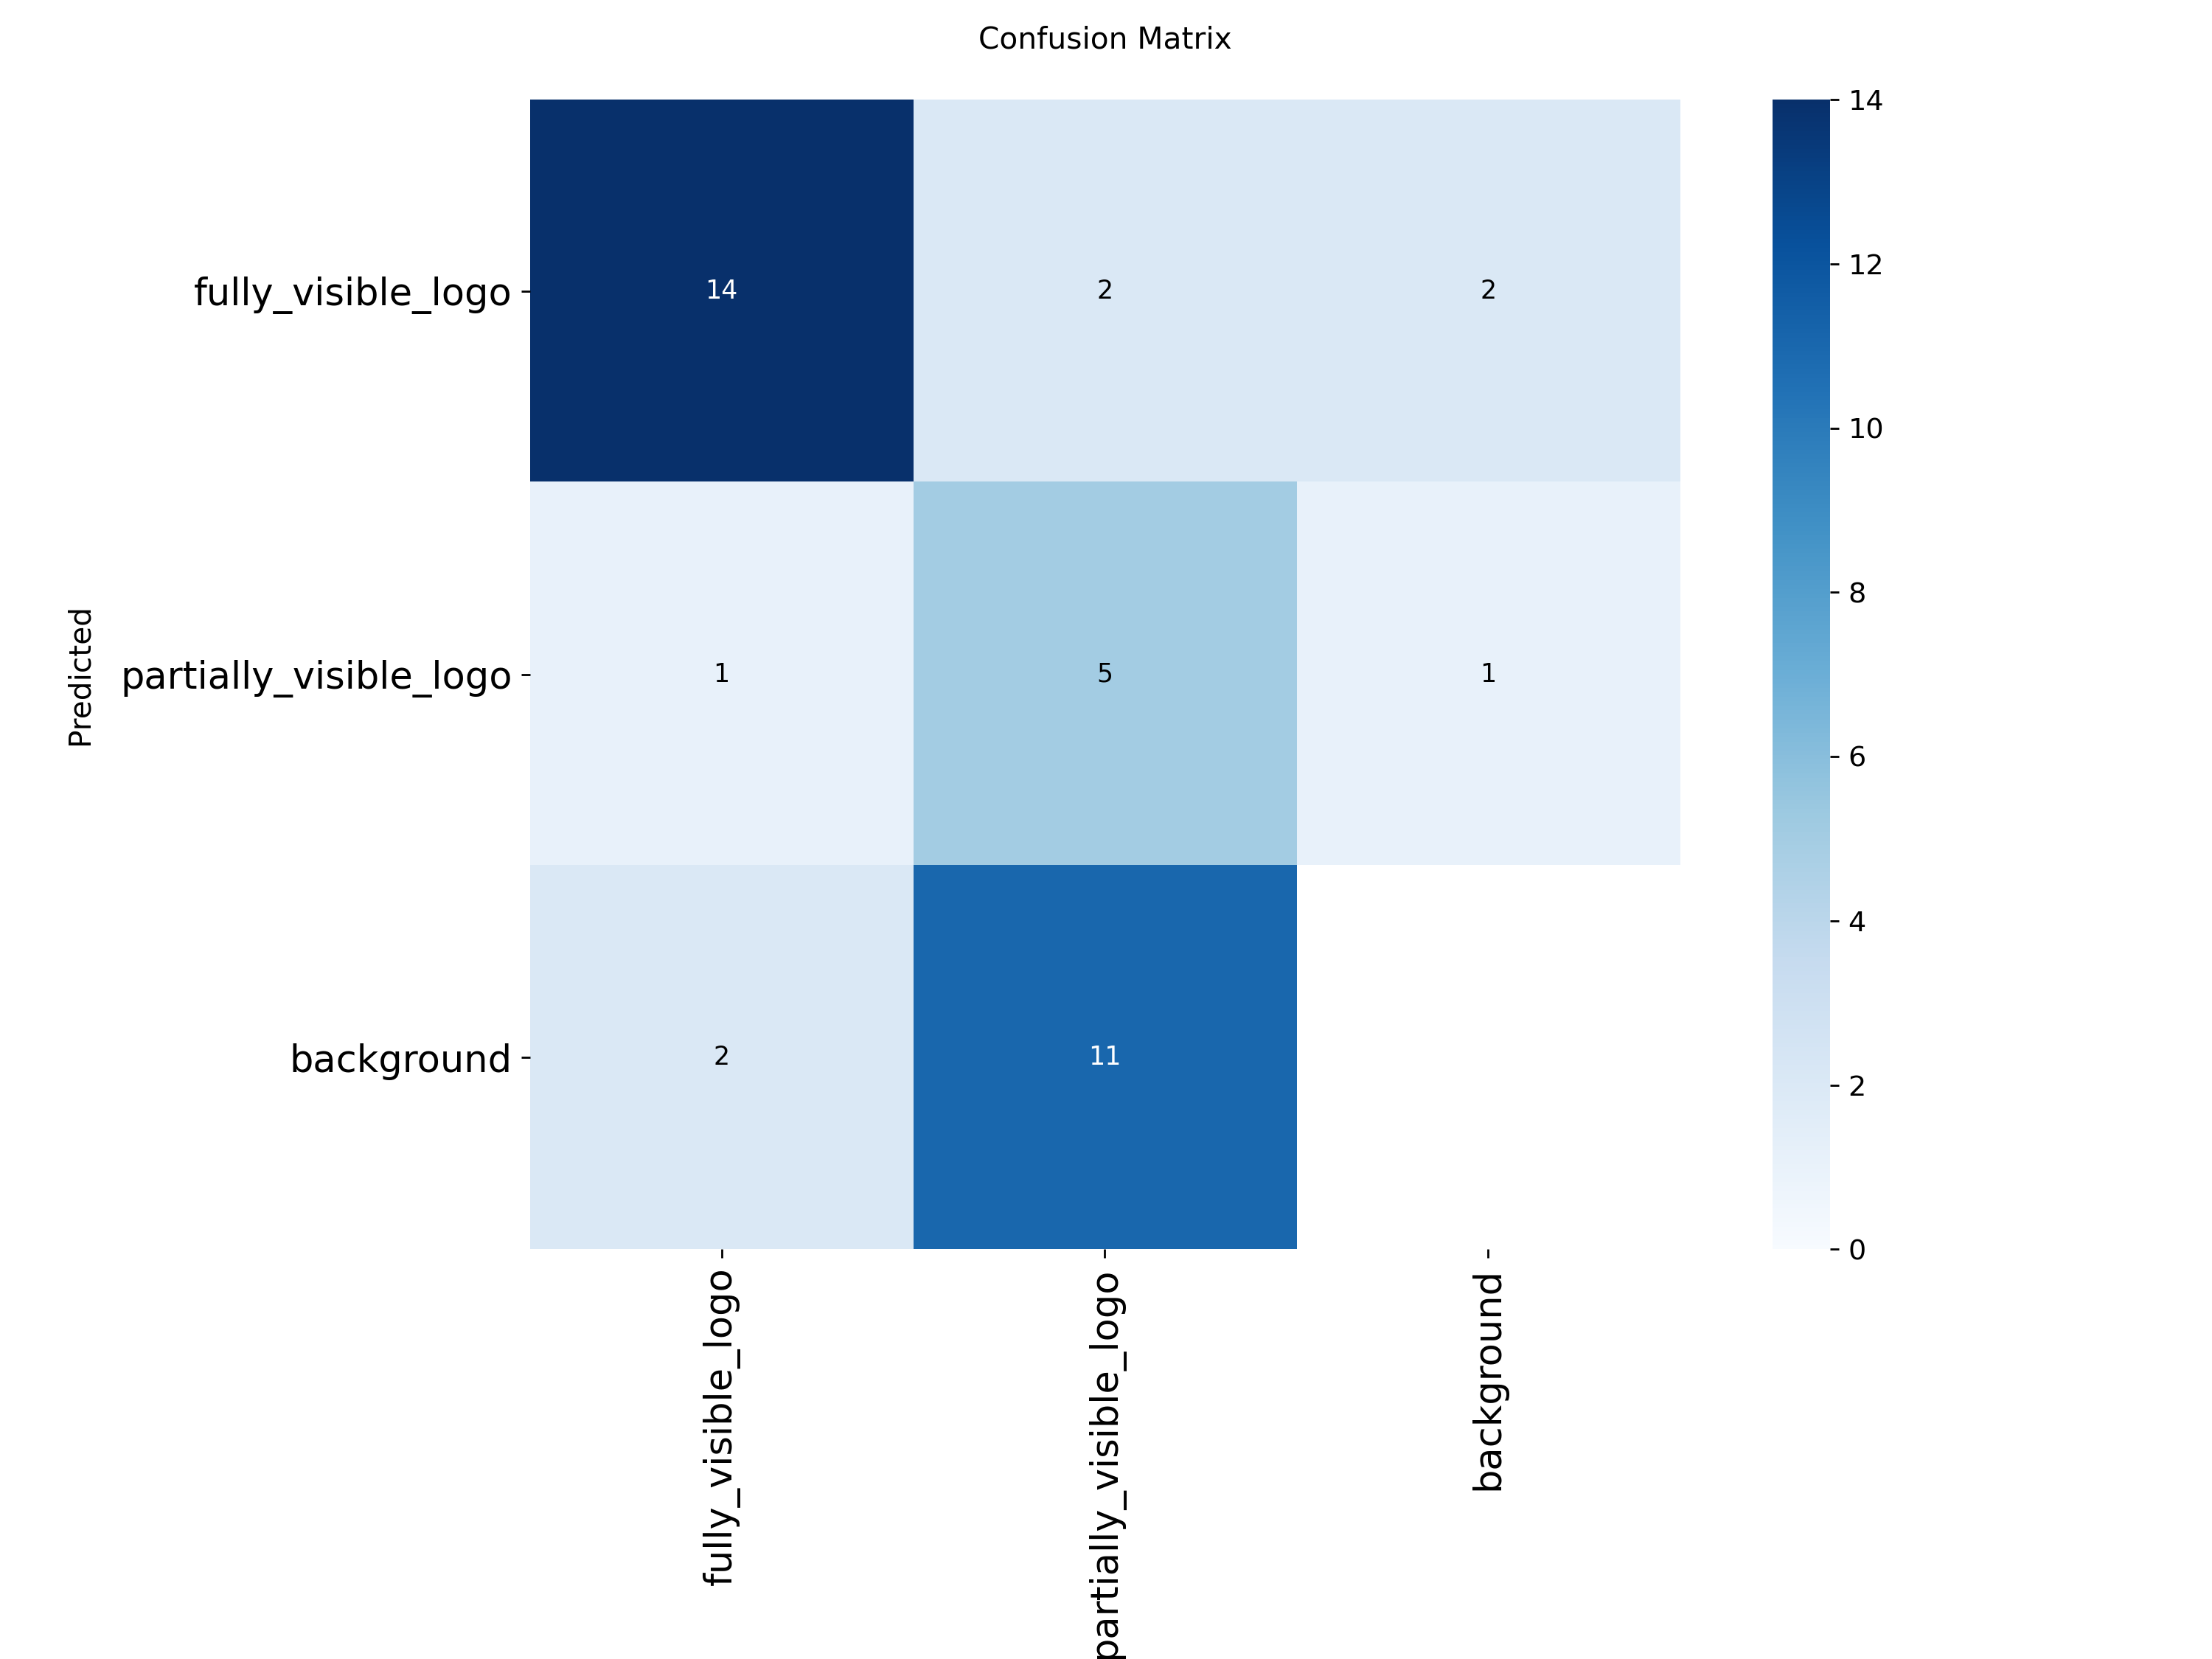

In [76]:
display(Image("/kaggle/working/runs/detect/val2/confusion_matrix.png"))

# Confusion Matrix Analysis

The confusion matrix provides a detailed view of how the model classifies *fully visible logos, partially visible logos, and background regions*.

The model performs well for *fully visible logos, correctly identifying **14 instances*, with only a few misclassifications as partially visible or background. This confirms the earlier metrics showing strong performance on clear and complete logos.

For *partially visible logos, the model correctly detects **5 instances*, but some are misclassified as fully visible logos or background. This indicates that the model finds it harder to recognize logos when they are partially occluded.

The matrix also shows several *background predictions*, suggesting that some regions without logos are incorrectly detected as objects. This contributes to false positives and slightly reduces overall precision.

Overall, the confusion matrix highlights that the model is *strong at detecting clear logos but struggles with partially visible ones*, which is consistent with the earlier evaluation metrics and confidence curves.

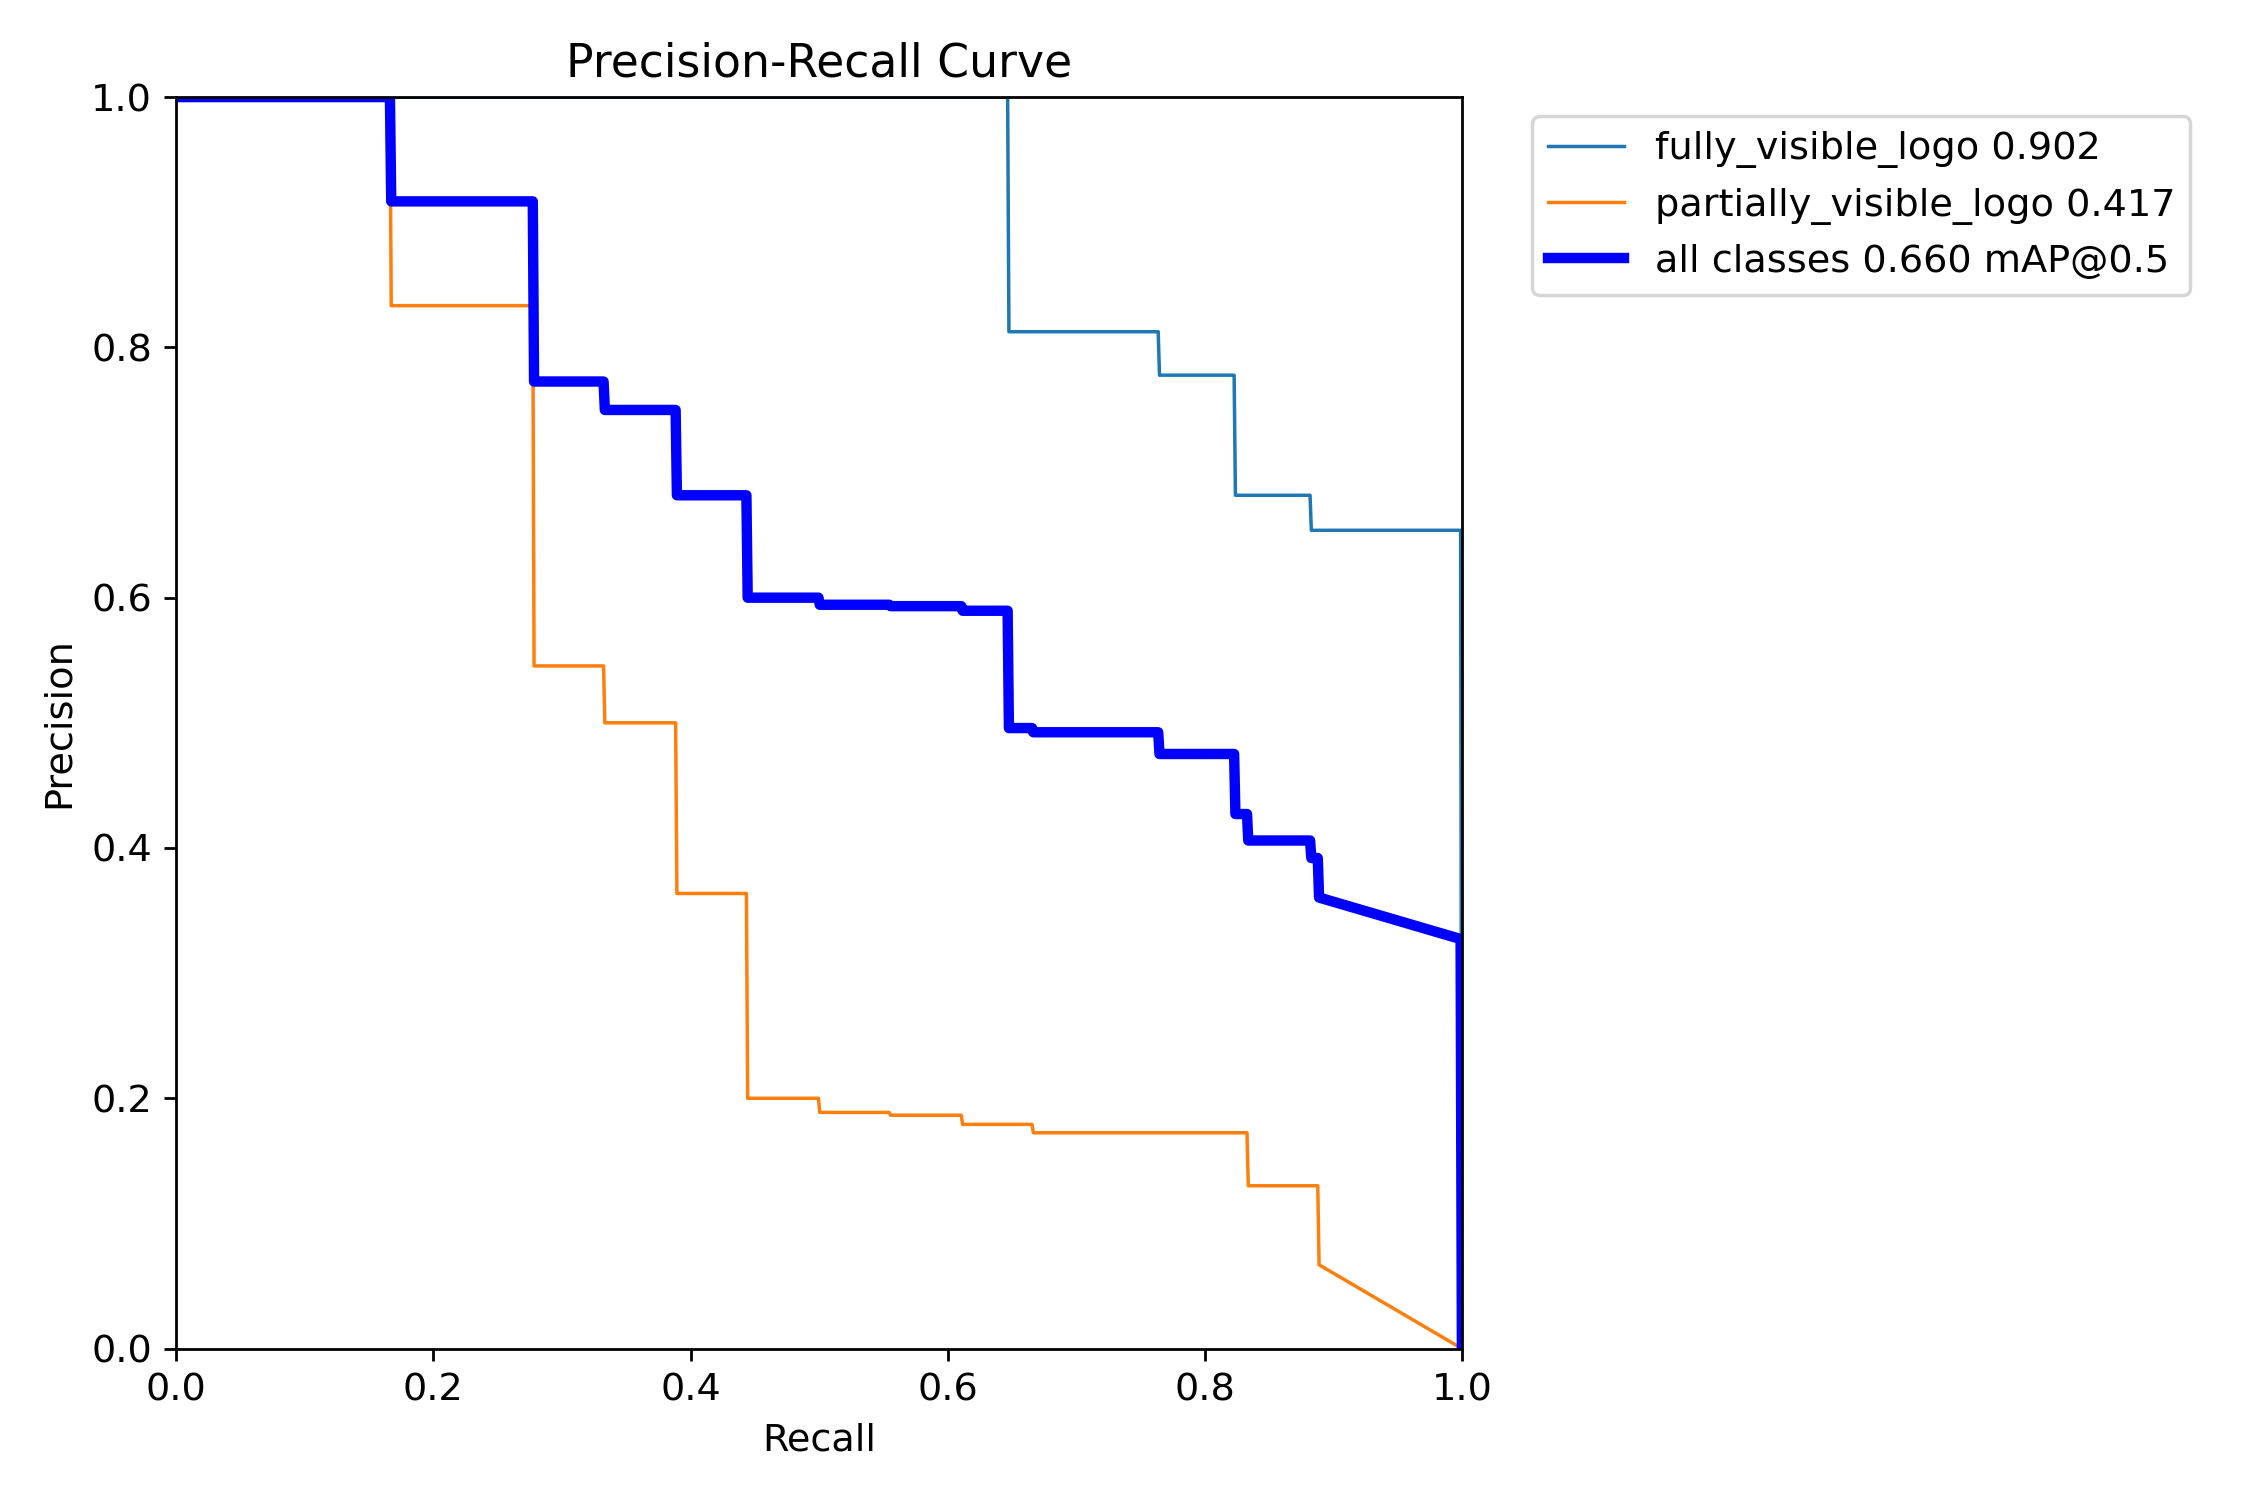

In [78]:
display(Image("/kaggle/working/runs/detect/val2/BoxPR_curve.png"))

## Precision–Recall Curve Analysis

The Precision–Recall curve shows the trade-off between precision and recall for different confidence thresholds. The area under this curve represents the *Average Precision (AP)* for each class.

For *fully visible logos, the curve stays high across most recall values, achieving an **AP of 0.902**, indicating that the model detects clear logos with high accuracy and consistency.

For *partially visible logos, the curve drops more quickly, with an **AP of 0.417**, suggesting that the model struggles to maintain precision as recall increases due to occlusions and incomplete visual features.

Overall, the model achieves an **mAP@0.5 of 0.660**, demonstrating strong performance for clear logos while highlighting challenges in detecting partially visible logos.

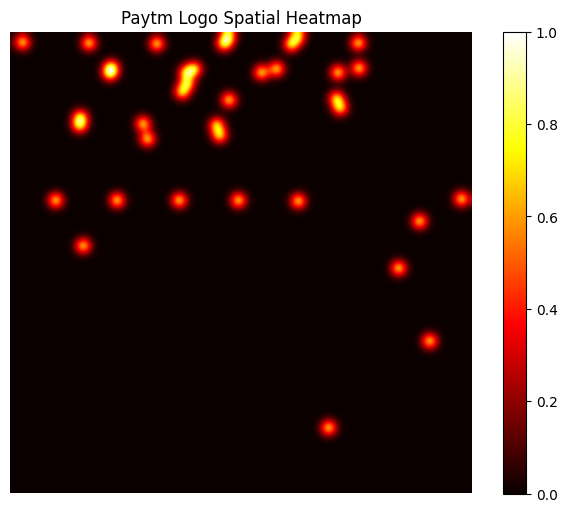

In [82]:
heatmap = np.zeros((640,640))

image_folder = "//kaggle/input/datasets/sairahul320388/paytm-logo-detection/valid/images"

for img_name in os.listdir(image_folder):

    img_path = os.path.join(image_folder, img_name)

    results = model.predict(img_path, conf=0.25, verbose=False)

    img = cv2.imread(img_path)
    img = cv2.resize(img, (640,640))

    for r in results:
        boxes = r.boxes.xyxy.cpu().numpy()

        for box in boxes:
            x1, y1, x2, y2 = box

            cx = int((x1 + x2) / 2)
            cy = int((y1 + y2) / 2)

            heatmap[cy, cx] += 1

heatmap = cv2.GaussianBlur(heatmap, (51,51), 0)
heatmap = heatmap / np.max(heatmap)

plt.figure(figsize=(8,6))
plt.imshow(heatmap, cmap='hot')
plt.title("Paytm Logo Spatial Heatmap")
plt.colorbar()
plt.axis("off")
plt.show()



# Paytm Logo Spatial Heatmap Analysis

The spatial heatmap visualizes the locations where the YOLO model most frequently detects Paytm logos across the validation dataset. Each detection contributes to the heatmap based on the center of its bounding box, allowing us to observe the spatial distribution of logo occurrences.

Brighter regions in the heatmap represent areas where logos are detected more frequently. The visualization shows that most detections occur in the *upper regions of the images*, suggesting that Paytm logos often appear in similar spatial positions such as banners or advertising boards.

Conversely, the lower regions of the heatmap contain very few detections, indicating that logos rarely appear in those areas. This spatial pattern highlights the *non-uniform distribution of logos within the dataset*.

Overall, the heatmap provides useful insight into where logos are typically located in images and demonstrates the model’s ability to consistently detect logos in those regions.

# **Business Insight from Logo Spatial Heatmap**

The spatial heatmap reveals that Paytm logos are most frequently detected in the upper regions of the frames. This suggests that advertisement boards located in these areas are more likely to be captured by broadcast cameras during sports coverage.

From a business perspective, this insight can help brands optimize advertisement placement to maximize on-screen visibility. Sponsors can prioritize positions that are frequently captured by cameras while avoiding areas with low visibility.

Such analysis can also be used to estimate brand exposure frequency and evaluate the return on investment (ROI) for sponsorship placements during live events.

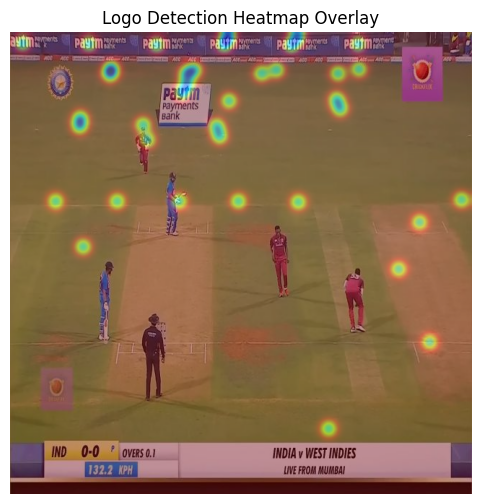

In [83]:
sample_img = cv2.imread(img_path)
sample_img = cv2.resize(sample_img, (640,640))
sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)

heatmap_color = cv2.applyColorMap(
    np.uint8(255*heatmap), cv2.COLORMAP_JET
)

overlay = cv2.addWeighted(sample_img, 0.6, heatmap_color, 0.4, 0)

plt.figure(figsize=(8,6))
plt.imshow(overlay)
plt.title("Logo Detection Heatmap Overlay")
plt.axis("off")
plt.show()

# Logo Detection Heatmap Overlay

To better understand where logos appear in broadcast frames, a spatial heatmap was overlaid on a sample image. The heatmap highlights regions where the model frequently detects logos across the dataset.

Bright regions indicate areas with higher detection frequency, while darker regions represent areas with fewer detections. Most hotspots appear along the stadium boundary boards and upper sections of the frame, which aligns with typical advertisement placements during cricket broadcasts.

This visualization helps identify regions with the highest brand exposure, providing valuable insights into advertisement placement effectiveness during televised matches.

# Predict on Test Images

In [63]:
results = model_yolo_final.predict(
    source="/kaggle/input/datasets/sairahul320388/paytm-logo-detection/test/images",
    conf=0.5,
    save=True
)


image 1/15 /kaggle/input/datasets/sairahul320388/paytm-logo-detection/test/images/INDIA-VS-WEST-INDIES-T20-FINAL-MATCH-FULL-MATCH-HIGHLIGHTS-_-IND-VS-WI-MOST-THRILLING-EVER-online-video-cutter_com-_mp4-0086_jpg.rf.0f5fe8468c35d68a17b1d2a2b1d287f8.jpg: 512x512 (no detections), 6.4ms
image 2/15 /kaggle/input/datasets/sairahul320388/paytm-logo-detection/test/images/INDIA-VS-WEST-INDIES-T20-FINAL-MATCH-FULL-MATCH-HIGHLIGHTS-_-IND-VS-WI-MOST-THRILLING-EVER-online-video-cutter_com-_mp4-0205_jpg.rf.77e29d04a534e3ed355d83985b2b2c4e.jpg: 512x512 (no detections), 5.8ms
image 3/15 /kaggle/input/datasets/sairahul320388/paytm-logo-detection/test/images/INDIA-VS-WEST-INDIES-T20-FINAL-MATCH-FULL-MATCH-HIGHLIGHTS-_-IND-VS-WI-MOST-THRILLING-EVER-online-video-cutter_com-_mp4-0212_jpg.rf.ddc569ddff0ee0c5900b2b1447120458.jpg: 512x512 (no detections), 5.8ms
image 4/15 /kaggle/input/datasets/sairahul320388/paytm-logo-detection/test/images/INDIA-VS-WEST-INDIES-T20-FINAL-MATCH-FULL-MATCH-HIGHLIGHTS-_-IND-VS-

# Run Inference On Sample Image


image 1/1 /kaggle/input/datasets/sairahul320388/paytm-logo-detection/valid/images/INDIA-VS-WEST-INDIES-T20-FINAL-MATCH-FULL-MATCH-HIGHLIGHTS-_-IND-VS-WI-MOST-THRILLING-EVER-online-video-cutter_com-_mp4-0532_jpg.rf.6ff9fd62cf38b7c969a64cca592df4ba.jpg: 512x512 1 fully_visible_logo, 8.9ms
Speed: 2.3ms preprocess, 8.9ms inference, 1.5ms postprocess per image at shape (1, 3, 512, 512)


(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

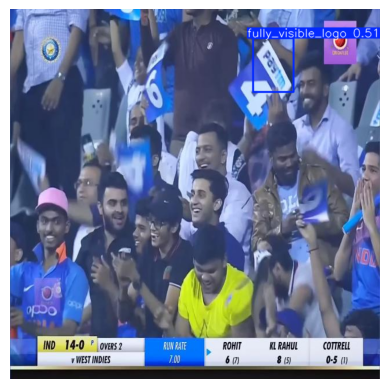

In [65]:
image_path = "/kaggle/input/datasets/sairahul320388/paytm-logo-detection/valid/images/INDIA-VS-WEST-INDIES-T20-FINAL-MATCH-FULL-MATCH-HIGHLIGHTS-_-IND-VS-WI-MOST-THRILLING-EVER-online-video-cutter_com-_mp4-0532_jpg.rf.6ff9fd62cf38b7c969a64cca592df4ba.jpg"

results = model_yolo_final(image_path)

img = results[0].plot()

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")

# Count Fully Visible , Partially Visible , Not Visible logos

In [66]:
test_folder = "/kaggle/input/datasets/sairahul320388/paytm-logo-detection/test/images"

fully_count = 0
partial_count = 0
no_logo_count = 0

for img_name in os.listdir(test_folder):

    img_path = os.path.join(test_folder, img_name)

    results = model_yolo_final(img_path, conf=0.5)

    boxes = results[0].boxes

    if boxes is None or len(boxes) == 0:
        no_logo_count += 1
        continue

    classes = boxes.cls.cpu().numpy()

    for c in classes:

        if int(c) == 0:
            fully_count += 1

        elif int(c) == 1:
            partial_count += 1


image 1/1 /kaggle/input/datasets/sairahul320388/paytm-logo-detection/test/images/INDIA-VS-WEST-INDIES-T20-FINAL-MATCH-FULL-MATCH-HIGHLIGHTS-_-IND-VS-WI-MOST-THRILLING-EVER-online-video-cutter_com-_mp4-0448_jpg.rf.71ce8f44175231e777c173e766980319.jpg: 512x512 (no detections), 8.2ms
Speed: 2.6ms preprocess, 8.2ms inference, 0.7ms postprocess per image at shape (1, 3, 512, 512)

image 1/1 /kaggle/input/datasets/sairahul320388/paytm-logo-detection/test/images/INDIA-VS-WEST-INDIES-T20-FINAL-MATCH-FULL-MATCH-HIGHLIGHTS-_-IND-VS-WI-MOST-THRILLING-EVER-online-video-cutter_com-_mp4-1168_jpg.rf.c3a89d14dd979c19c37368feb71deda9.jpg: 512x512 (no detections), 6.4ms
Speed: 1.8ms preprocess, 6.4ms inference, 0.5ms postprocess per image at shape (1, 3, 512, 512)

image 1/1 /kaggle/input/datasets/sairahul320388/paytm-logo-detection/test/images/INDIA-VS-WEST-INDIES-T20-FINAL-MATCH-FULL-MATCH-HIGHLIGHTS-_-IND-VS-WI-MOST-THRILLING-EVER-online-video-cutter_com-_mp4-1118_jpg.rf.f6321af7468e3c6b52d083bef03e

# Show Count

In [67]:
print("Fully Visible Logos:", fully_count)
print("Partially Visible Logos:", partial_count)
print("No Logo Detected:", no_logo_count)

Fully Visible Logos: 4
Partially Visible Logos: 0
No Logo Detected: 11


# **Function to Draw Bounding Boxes**

In [69]:
image_dir = "/kaggle/input/datasets/sairahul320388/paytm-logo-detection/train/images"
label_dir = "/kaggle/input/datasets/sairahul320388/paytm-logo-detection/train/labels"

def draw_boxes(img, labels):

    h, w, _ = img.shape

    for label in labels:

        cls, xc, yc, bw, bh = map(float, label.split())

        x1 = int((xc - bw/2) * w)
        y1 = int((yc - bh/2) * h)
        x2 = int((xc + bw/2) * w)
        y2 = int((yc + bh/2) * h)

        cv2.rectangle(img,(x1,y1),(x2,y2),(0,255,0),2)
        cv2.putText(img,"Fully Visible",(x1,y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX,0.6,(0,255,0),2)

    return img

# **Display Sample Fully Visible Logos**

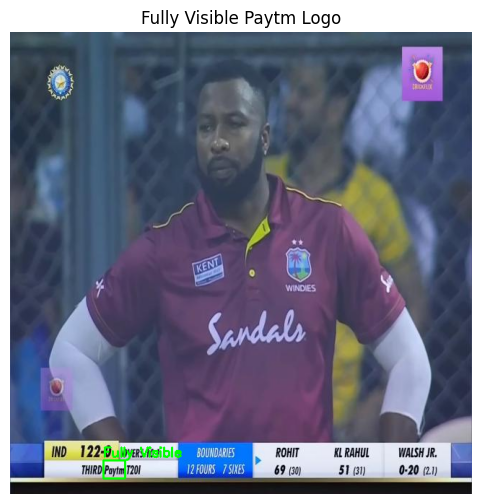

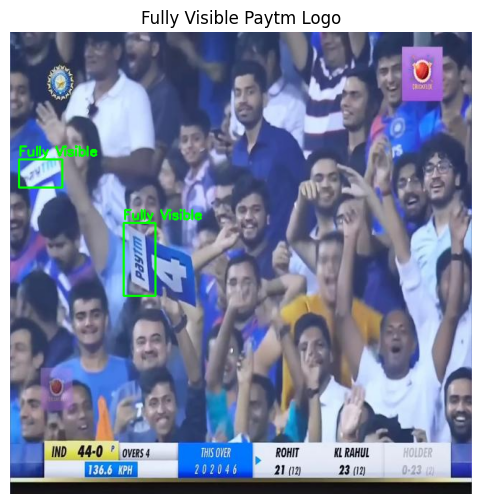

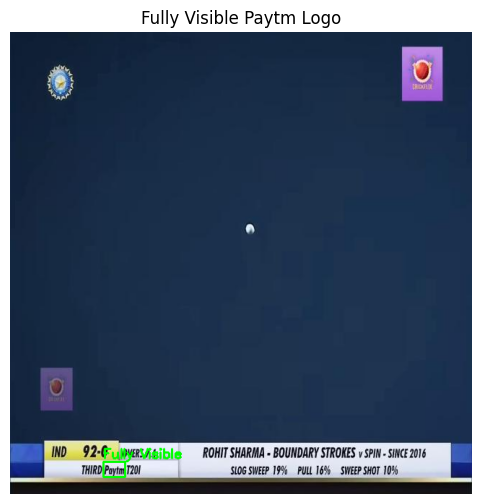

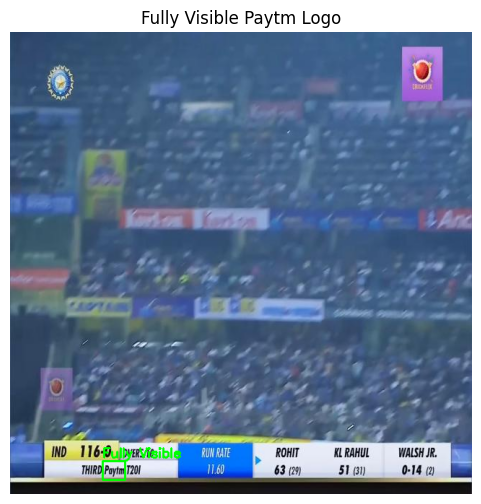

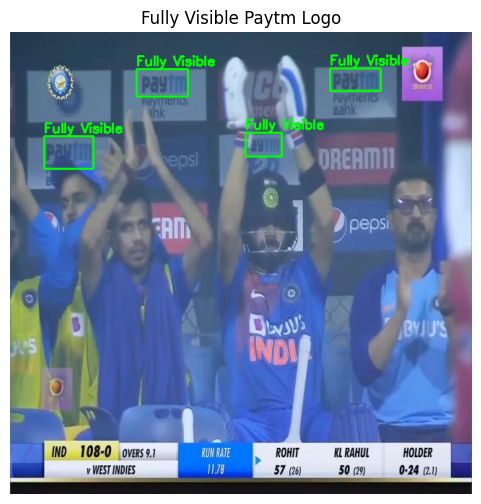

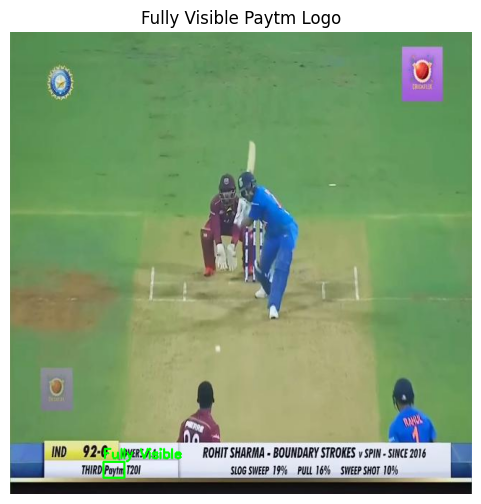

In [70]:
count = 0
max_images = 6

for file in os.listdir(label_dir):

    label_path = os.path.join(label_dir, file)

    with open(label_path) as f:
        lines = f.readlines()

    # Check if image contains fully visible class
    if any(line.startswith("0") for line in lines):

        img_name = file.replace(".txt",".jpg")
        img_path = os.path.join(image_dir,img_name)

        img = cv2.imread(img_path)

        img = draw_boxes(img, lines)

        plt.figure(figsize=(6,6))
        plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.title("Fully Visible Paytm Logo")

        count += 1

        if count >= max_images:
            break

# **Bounding Box Size Distribution Analysis**

In [71]:
widths = []
heights = []
areas = []

for file in os.listdir(label_dir):

    label_path = os.path.join(label_dir,file)

    with open(label_path) as f:
        lines = f.readlines()

    for line in lines:

        cls, xc, yc, w, h = map(float,line.split())

        widths.append(w)
        heights.append(h)
        areas.append(w*h)

# Bounding Box Area Distribution

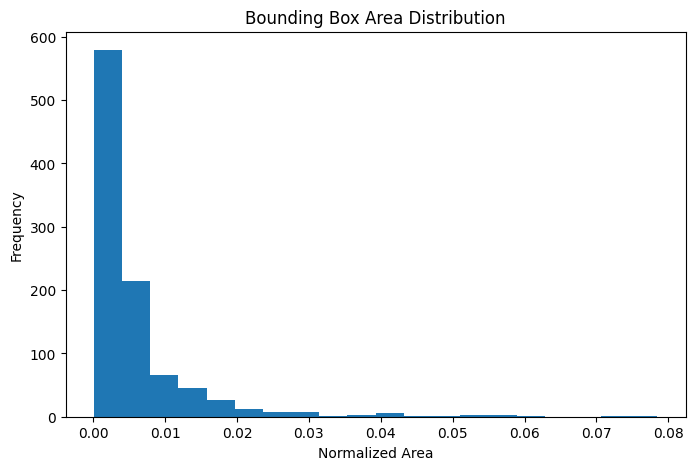

In [72]:
plt.figure(figsize=(8,5))

plt.hist(areas, bins=20)

plt.title("Bounding Box Area Distribution")
plt.xlabel("Normalized Area")
plt.ylabel("Frequency")

plt.show()

# Bounding Box Area Distribution

The histogram shows the distribution of normalized bounding box areas for detected logos in the dataset. Most bounding boxes are concentrated near very small area values, indicating that logos typically occupy a small portion of the frame.

This is expected in sports broadcast footage where advertisement boards are usually positioned at a distance from the camera. As a result, the majority of logos appear relatively small within the image.

The long-tail distribution also suggests that only a small number of frames contain large logos, which may correspond to zoomed-in shots or close-up camera angles.

Understanding this distribution is important for training object detection models, as detecting small objects requires higher resolution inputs and careful model tuning.

# Business Insight

The distribution suggests that brand logos usually appear small within broadcast frames, meaning that advertisement boards are typically positioned far from the camera.
For brands, this indicates that logo size and placement in stadium advertising boards must be optimized for visibility, especially during wide-angle broadcast shots.

# Width vs Height Scatter Plot

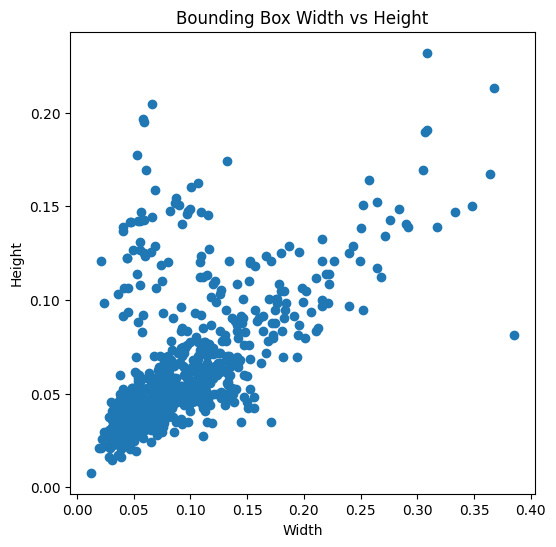

In [73]:
plt.figure(figsize=(6,6))

plt.scatter(widths,heights)

plt.title("Bounding Box Width vs Height")
plt.xlabel("Width")
plt.ylabel("Height")

plt.show()

# Bounding Box Width vs Height Distribution

The scatter plot visualizes the relationship between bounding box width and height for logo annotations in the dataset. Each point represents a detected logo, with the axes showing normalized width and height relative to the image dimensions.

Most bounding boxes are concentrated in the lower-left region of the plot, indicating that logos generally occupy a small portion of the frame. This is expected in sports broadcast footage where advertisement boards appear relatively far from the camera.

A small number of larger bounding boxes appear in the upper-right region, likely corresponding to zoomed-in shots or close-up camera angles. Understanding this distribution helps highlight the challenge of detecting small objects and emphasizes the importance of using high-resolution inputs during model training.

# Small / Medium / Large Object Distribution

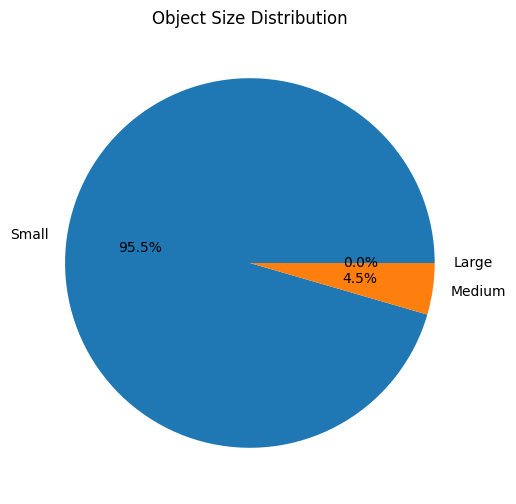

In [75]:
small = 0
medium = 0
large = 0

for area in areas:

    if area < 0.02:
        small += 1

    elif area < 0.15:
        medium += 1

    else:
        large += 1


labels = ["Small","Medium","Large"]
sizes = [small,medium,large]

plt.figure(figsize=(6,6))

plt.pie(sizes,labels=labels,autopct='%1.1f%%')

plt.title("Object Size Distribution")

plt.show()

# Video Based Logo Detection

In [94]:
video_path = "/kaggle/input/datasets/siddharth1008/match-video/match_video.mp4"

cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)


fully_visible_frames = 0
partially_visible_frames = 0
no_logo_frames = 0
total_frames = 0

# Timeline storage
timeline = []

# CSV storage
records = []

In [95]:
while cap.isOpened():

    ret, frame = cap.read()

    if not ret:
        break

    total_frames += 1

    results = model.predict(frame, conf=0.35, verbose=False)

    detected_class = "No Logo"

    for r in results:
        for box in r.boxes:

            class_id = int(box.cls)

            if class_id == 0:
                detected_class = "Fully Visible"

            elif class_id == 1:
                detected_class = "Partially Visible"

    # Update counters
    if detected_class == "Fully Visible":
        fully_visible_frames += 1
        timeline.append(2)

    elif detected_class == "Partially Visible":
        partially_visible_frames += 1
        timeline.append(1)

    else:
        no_logo_frames += 1
        timeline.append(0)

    # Calculate timestamp
    timestamp = total_frames / fps

    # Save record
    records.append({
        "frame": total_frames,
        "time_seconds": round(timestamp,2),
        "visibility": detected_class
    })

cap.release()

# Exposure time
fully_time = fully_visible_frames / fps
partial_time = partially_visible_frames / fps
total_exposure = fully_time + partial_time

print("Video FPS:", fps)
print("Total Frames:", total_frames)

print("\n---- Exposure Report ----")

print("Fully Visible Time:", round(fully_time,2), "seconds")
print("Partially Visible Time:", round(partial_time,2), "seconds")
print("Total Logo Exposure:", round(total_exposure,2), "seconds")

print("\nFrame Counts")

print("Fully Visible Frames:", fully_visible_frames)
print("Partially Visible Frames:", partially_visible_frames)
print("No Logo Frames:", no_logo_frames)

Video FPS: 30.0
Total Frames: 14454

---- Exposure Report ----
Fully Visible Time: 40.83 seconds
Partially Visible Time: 5.53 seconds
Total Logo Exposure: 46.37 seconds

Frame Counts
Fully Visible Frames: 1225
Partially Visible Frames: 166
No Logo Frames: 13063


# Logo Exposure Analysis from Match Video

To evaluate real-world brand visibility, the trained YOLOv8 model was applied to a cricket match video. The video was processed frame-by-frame to detect Paytm logos and measure their appearance throughout the broadcast.

The analysis shows that the logo was fully visible in **1225 frames** and partially visible in *166 frames, resulting in approximately **46.37 seconds** of total logo exposure. Out of this, **40.83 seconds correspond to clearly visible logos, while **5.53 seconds** represent partially visible instances*.

Considering the video runs at *30 FPS, the total exposure represents roughly **10% of the broadcast duration**. This demonstrates how computer vision can automatically measure advertisement visibility and estimate brand exposure in sports broadcasts, providing valuable insights for sponsorship evaluation and marketing analytics.

In [102]:
df.sample(10)

,frame,time_seconds,visibility
1425,1426,47.53,No Logo
10713,10714,357.13,No Logo
7803,7804,260.13,No Logo
13580,13581,452.70,No Logo
9924,9925,330.83,No Logo
1603,1604,53.47,No Logo
5470,5471,182.37,No Logo
488,489,16.30,Fully Visible
11920,11921,397.37,No Logo
8073,8074,269.13,No Logo


# Save CSV File

In [96]:
df = pd.DataFrame(records)

csv_path = "/kaggle/working/logo_visibility_timeline.csv"

df.to_csv(csv_path, index=False)

print("CSV saved at:", csv_path)

CSV saved at: /kaggle/working/logo_visibility_timeline.csv


# **Logo Exposure Time Bar Chart**

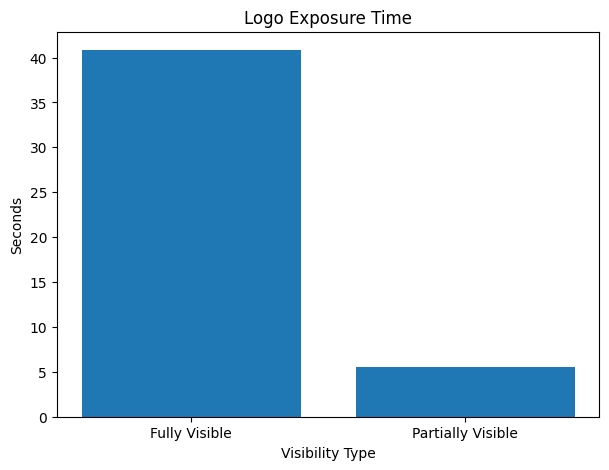

In [97]:
times = [fully_time, partial_time]

labels = ["Fully Visible", "Partially Visible"]

plt.figure(figsize=(7,5))
plt.bar(labels, times)

plt.title("Logo Exposure Time")
plt.ylabel("Seconds")
plt.xlabel("Visibility Type")

plt.show()

# Frame Count Comparison

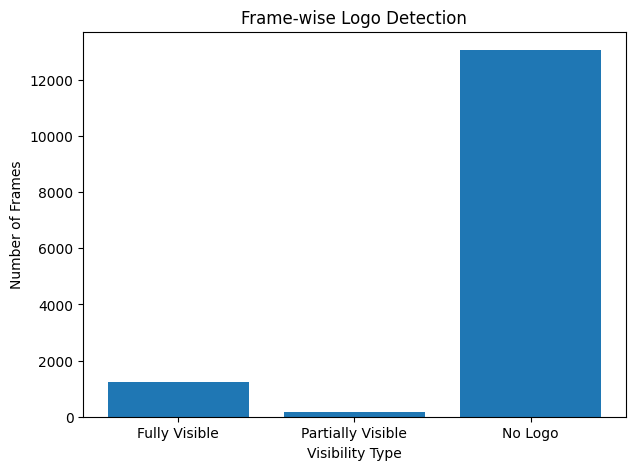

In [98]:
frames = [fully_visible_frames, partially_visible_frames, no_logo_frames]

labels = ["Fully Visible", "Partially Visible", "No Logo"]

plt.figure(figsize=(7,5))
plt.bar(labels, frames)

plt.title("Frame-wise Logo Detection")
plt.ylabel("Number of Frames")
plt.xlabel("Visibility Type")

plt.show()

# Visibility Rate

In [99]:
visibility_rate = total_exposure / (total_frames / fps)

print("\nVisibility Rate:", round(visibility_rate*100,2), "%")



Visibility Rate: 9.62 %


# Visibility Pie Chart

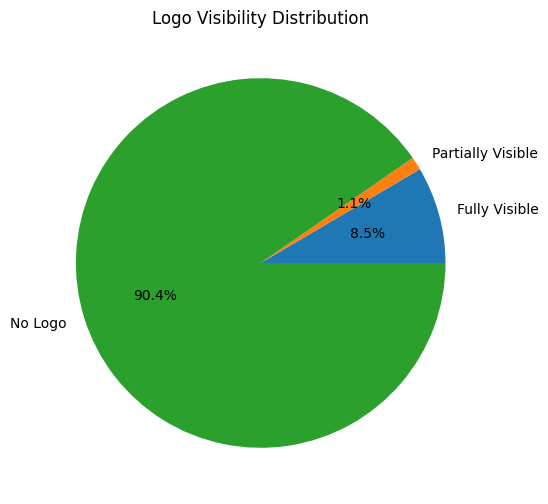

In [100]:
labels = ["Fully Visible","Partially Visible","No Logo"]

sizes = [
    fully_visible_frames,
    partially_visible_frames,
    no_logo_frames
]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title("Logo Visibility Distribution")
plt.show()